# Static–Dynamic and Multimodal Error Analysis

This notebook analyzes the final prediction CSV files for the static and dynamic FER settings.

It covers:

1. Static and dynamic confusion matrices for Image, FEA, and Multimodal FER.
2. Static → Dynamic changes at the overall, class, and sample level for each modality.
3. Pairwise comparisons within the dynamic setting, with emphasis on Image → Multimodal and FEA → Multimodal.
4. Changes in the most frequent error pairs.
5. Fusion performance within the four joint unimodal correctness groups, for Static and Dynamic.
6. A compact Markdown error-analysis report and reproducible CSV/figure exports.

**Analysis units:** Image and Multimodal use 756 view-level samples. FEA produces one prediction per reenactment, duplicated across Central and Side rows in the CSV; FEA-only analyses therefore deduplicate to 378 reenactments. Cross-modality comparisons involving FEA and a view-specific model use the 756 aligned view rows for descriptive pairing, but the duplicated FEA decisions must not be interpreted as 756 independent observations.

**Run:** place the notebook beside `static_test_predictions.csv` and `dynamic_test_predictions.csv`, then run all cells in order. Dependencies: NumPy, pandas, Matplotlib, seaborn, and scikit-learn. The notebook writes the report, figures, tables, and structural validation summary under `outputs/`. Only aggregate plots are generated; no source images are displayed. Significance tests remain in the separate statistical-test notebooks.


## 1. Setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize


STATIC_PATH = Path("static_test_predictions.csv")
DYNAMIC_PATH = Path("dynamic_test_predictions.csv")

OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]
CLASS_IDS = np.arange(len(CLASSES))
MODALITIES = ["image", "fea", "multimodal"]
DISPLAY = {"image": "Image", "fea": "FEA", "multimodal": "Multimodal"}

# Publication-oriented visual defaults.
sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.15,
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 12,
        "axes.labelsize": 10.5,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    },
)

# Colorblind-safe, restrained palette inspired by Okabe-Ito.
STATIC_COLOR = "#6B7280"
DYNAMIC_COLOR = "#0072B2"
MODALITY_COLORS = {
    "Image": "#0072B2",
    "FEA": "#D55E00",
    "Multimodal": "#009E73",
}
POSITIVE_COLOR = "#009E73"
NEGATIVE_COLOR = "#D55E00"
NEUTRAL_COLOR = "#999999"
TRANSITION_COLORS = {
    "both_correct": "#009E73",
    "static_only_correct": "#D55E00",
    "dynamic_only_correct": "#56B4E9",
    "both_wrong": "#999999",
    "base_only_correct": "#D55E00",
    "target_only_correct": "#56B4E9",
}


def finish_figure(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def modality_unit(df, modality):
    if modality == "fea":
        out = (
            df.sort_values(["reenactment_id", "camera_index"])
              .drop_duplicates("reenactment_id")
              .copy()
        )
        return out, "reenactment_id", "reenactment"

    return df.copy(), "sample_id", "view sample"


def add_correctness(df, modality, column="correct"):
    out = df.copy()
    out[column] = out[f"{modality}_pred_id"].to_numpy() == out["true_label_id"].to_numpy()
    return out


def confusion_annotations(cm):
    """Return count + row-percentage labels for a confusion matrix."""
    cm = np.asarray(cm)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_pct = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    )

    labels = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            labels[i, j] = f"{cm[i, j]}\n{100 * row_pct[i, j]:.1f}%"

    return row_pct, labels


def add_bar_labels(ax, fmt="{:.1%}", padding=3):
    for container in ax.containers:
        labels = [fmt.format(bar.get_height()) for bar in container]
        ax.bar_label(container, labels=labels, padding=padding, fontsize=8.5)


# Publication-style sequential colormap for prediction-overlap heatmaps.
_blues = plt.get_cmap("Blues")
_overlap_stops = [(x * 0.88, _blues(x)) for x in np.linspace(0, 1, 12)]
OVERLAP_CMAP = LinearSegmentedColormap.from_list(
    "extended_blues",
    _overlap_stops + [(1, "#02060c")],
)
OVERLAP_NORM = Normalize(0, 100)


def overlap_counts_by_class(df, first_correct_col, second_correct_col):
    """
    Return 4 x 7 counts:
    both correct, only second correct, only first correct, both incorrect.
    """
    rows = []
    for class_id in CLASS_IDS:
        g = df[df["true_label_id"] == class_id]
        first = g[first_correct_col].to_numpy(dtype=bool)
        second = g[second_correct_col].to_numpy(dtype=bool)

        rows.append([
            int((first & second).sum()),
            int((~first & second).sum()),
            int((first & ~second).sum()),
            int((~first & ~second).sum()),
        ])

    return np.asarray(rows, dtype=int).T


def draw_overlap_heatmap(ax, counts, row_labels, title):
    """
    Draw class-wise overlap counts with percentages normalized within true class.
    Each column therefore sums to 100%.
    """
    percentages = 100 * counts / counts.sum(axis=0, keepdims=True)

    sns.heatmap(
        percentages,
        ax=ax,
        cmap=OVERLAP_CMAP,
        norm=OVERLAP_NORM,
        cbar=False,
        square=True,
        xticklabels=CLASSES,
        yticklabels=row_labels,
        linewidths=0.7,
        linecolor="white",
    )

    for (row, col), count in np.ndenumerate(counts):
        rgb = np.array(OVERLAP_CMAP(OVERLAP_NORM(percentages[row, col]))[:3])
        linear = np.where(
            rgb <= 0.04045,
            rgb / 12.92,
            ((rgb + 0.055) / 1.055) ** 2.4,
        )
        text_color = (
            "white"
            if linear @ [0.2126, 0.7152, 0.0722] < 0.179
            else "#161b22"
        )

        ax.text(
            col + 0.5,
            row + 0.40,
            str(count),
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color=text_color,
        )
        ax.text(
            col + 0.5,
            row + 0.69,
            f"{percentages[row, col]:.1f}%",
            ha="center",
            va="center",
            fontsize=7.8,
            color=text_color,
        )

    ax.set_title(title, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=35, length=0, pad=6)
    ax.tick_params(axis="y", rotation=0, length=0, pad=6)

    return percentages


## 2. Input validation and alignment

In [2]:
static = pd.read_csv(STATIC_PATH)
dynamic = pd.read_csv(DYNAMIC_PATH)

assert len(static) == 756
assert len(dynamic) == 756
assert static["sample_id"].is_unique
assert dynamic["sample_id"].is_unique
assert static["reenactment_id"].nunique() == 378
assert dynamic["reenactment_id"].nunique() == 378

metadata_columns = [
    "sample_id",
    "reenactment_id",
    "timestamp",
    "set_id",
    "participant_id",
    "level_id",
    "emoji_id",
    "camera_index",
    "perspective",
    "true_label_id",
    "true_label",
]

for column in metadata_columns:
    assert np.array_equal(
        static[column].to_numpy(),
        dynamic[column].to_numpy(),
    ), f"Static/dynamic mismatch in {column}"

assert set(static["perspective"]) == {"Central", "Side"}
assert set(dynamic["perspective"]) == {"Central", "Side"}

# FEA predictions must be identical for the two view rows belonging to a reenactment.
for setting_name, df in [("Static", static), ("Dynamic", dynamic)]:
    assert df.groupby("reenactment_id")["fea_pred_id"].nunique().eq(1).all()
    for class_name in [c.lower() for c in CLASSES]:
        assert (
            df.groupby("reenactment_id")[f"fea_prob_{class_name}"]
              .nunique()
              .eq(1)
              .all()
        ), f"{setting_name} FEA probabilities differ between paired view rows"

# Prediction IDs and names must agree.
for df in [static, dynamic]:
    for modality in MODALITIES:
        expected_names = pd.Series(df[f"{modality}_pred_id"]).map(dict(enumerate(CLASSES))).to_numpy()
        assert np.array_equal(expected_names, df[f"{modality}_pred"].to_numpy())

# Check the assumptions used by deduplication and count alignment.
for setting_name, df in [("Static", static), ("Dynamic", dynamic)]:
    required = metadata_columns + [f"{m}_pred_id" for m in MODALITIES]
    assert df[required].notna().all().all(), f"{setting_name}: missing required values"
    assert df.groupby("reenactment_id").size().eq(2).all()
    assert df.groupby("reenactment_id")["perspective"].agg(set).map(
        lambda views: views == {"Central", "Side"}
    ).all()
    assert df.groupby("reenactment_id")["participant_id"].nunique().eq(1).all()
    assert df.groupby("reenactment_id")["true_label_id"].nunique().eq(1).all()
    assert df["true_label_id"].isin(CLASS_IDS).all()
    assert np.array_equal(
        df["true_label_id"].map(dict(enumerate(CLASSES))).to_numpy(),
        df["true_label"].to_numpy(),
    )
    for modality in MODALITIES:
        assert df[f"{modality}_pred_id"].isin(CLASS_IDS).all()

print("Static rows:", len(static))
print("Dynamic rows:", len(dynamic))
print("Reenactments:", dynamic["reenactment_id"].nunique())
print("Participants:", dynamic["participant_id"].nunique())
print("Static/dynamic metadata and FEA duplication checks passed.")


Static rows: 756
Dynamic rows: 756
Reenactments: 378
Participants: 8
Static/dynamic metadata and FEA duplication checks passed.


In [3]:
validation = {
    "rows_per_file": len(dynamic),
    "reenactments": int(dynamic["reenactment_id"].nunique()),
    "participants": int(dynamic["participant_id"].nunique()),
    "classes": CLASSES,
    "metadata_alignment_passed": True,
    "paired_views_passed": True,
    "fea_duplication_checks_passed": True,
}

with open(OUTPUT_DIR / "validation.json", "w", encoding="utf-8") as f:
    json.dump(validation, f, indent=2)

validation


{'rows_per_file': 756,
 'reenactments': 378,
 'participants': 8,
 'classes': ['Anger',
  'Disgust',
  'Fear',
  'Happiness',
  'Neutral',
  'Sadness',
  'Surprise'],
 'metadata_alignment_passed': True,
 'paired_views_passed': True,
 'fea_duplication_checks_passed': True}

## 3. Confusion matrices: Static and Dynamic

For the publication-oriented confusion matrices, the **color encodes row-normalized percentages**, while each cell is annotated with **both the absolute count and the row percentage**.

This is preferable here because Image/Multimodal have 108 samples per class, whereas FEA has 54 reenactments per class. Counts preserve the exact number of errors, while percentages make the modalities directly comparable despite the different analysis-unit counts.


In [4]:
confusion_records = []
performance_records = []
class_metric_records = []
confusion_cache = {}

for setting_name, df in [("Static", static), ("Dynamic", dynamic)]:
    for modality in MODALITIES:
        unit_df, _, unit_name = modality_unit(df, modality)
        unit_df = add_correctness(unit_df, modality)

        y_true = unit_df["true_label_id"].to_numpy()
        y_pred = unit_df[f"{modality}_pred_id"].to_numpy()

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=CLASS_IDS,
        )
        confusion_cache[(setting_name, modality)] = cm

        precision, recall, f1, support = precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=CLASS_IDS,
            zero_division=0,
        )
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=CLASS_IDS,
            average="macro",
            zero_division=0,
        )

        performance_records.append({
            "setting": setting_name,
            "modality": DISPLAY[modality],
            "analysis_unit": unit_name,
            "n": len(unit_df),
            "correct": int(unit_df["correct"].sum()),
            "accuracy": float(unit_df["correct"].mean()),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
        })

        for class_id, class_name in enumerate(CLASSES):
            class_metric_records.append({
                "setting": setting_name,
                "modality": DISPLAY[modality],
                "class": class_name,
                "support": int(support[class_id]),
                "precision": float(precision[class_id]),
                "recall": float(recall[class_id]),
                "f1": float(f1[class_id]),
            })

        for i, true_class in enumerate(CLASSES):
            for j, predicted_class in enumerate(CLASSES):
                confusion_records.append({
                    "setting": setting_name,
                    "modality": DISPLAY[modality],
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "count": int(cm[i, j]),
                    "row_fraction": float(cm[i, j] / cm[i].sum()),
                })

performance = pd.DataFrame(performance_records)
class_metrics = pd.DataFrame(class_metric_records)
confusion_long = pd.DataFrame(confusion_records)

performance


,setting,modality,analysis_unit,n,correct,accuracy,macro_precision,macro_recall,macro_f1
0,Static,Image,view sample,756,528,0.698413,0.713252,0.698413,0.700561
1,Static,FEA,reenactment,378,271,0.716931,0.723777,0.716931,0.711015
2,Static,Multimodal,view sample,756,608,0.804233,0.808109,0.804233,0.802249
3,Dynamic,Image,view sample,756,550,0.727513,0.739744,0.727513,0.728686
4,Dynamic,FEA,reenactment,378,296,0.783069,0.798693,0.783069,0.777410
5,Dynamic,Multimodal,view sample,756,617,0.816138,0.831185,0.816138,0.814932


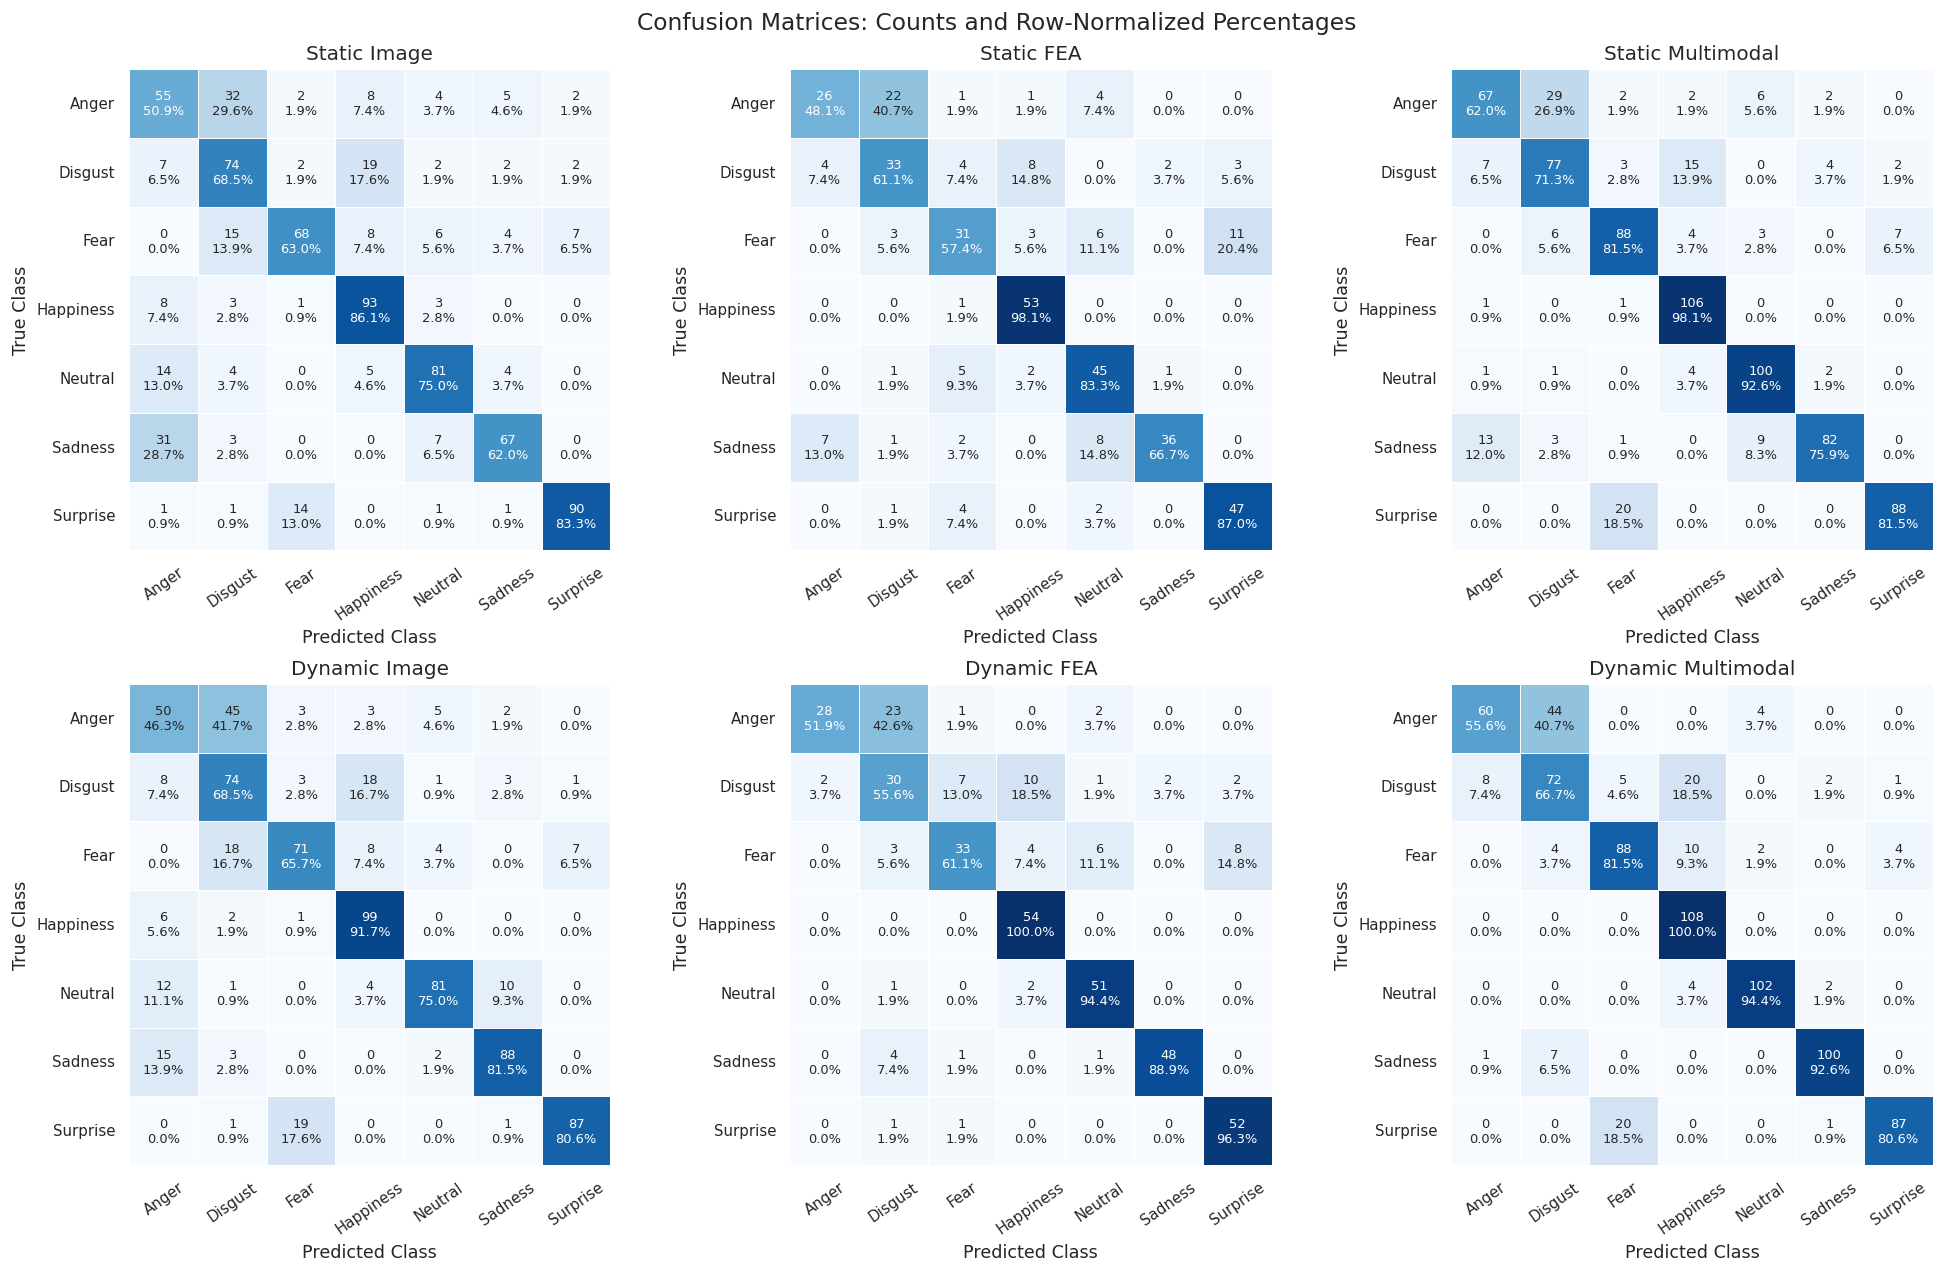

In [5]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16.5, 10.5),
    layout="constrained",
)

for row, setting_name in enumerate(["Static", "Dynamic"]):
    for col, modality in enumerate(MODALITIES):
        ax = axes[row, col]
        cm = confusion_cache[(setting_name, modality)]
        cm_norm, annotations = confusion_annotations(cm)

        sns.heatmap(
            cm_norm,
            annot=annotations,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            square=True,
            linewidths=0.6,
            linecolor="white",
            cbar=False,
            xticklabels=CLASSES,
            yticklabels=CLASSES,
            annot_kws={"fontsize": 7.8},
            ax=ax,
        )

        ax.set_title(f"{setting_name} {DISPLAY[modality]}")
        ax.set_xlabel("Predicted Class")
        ax.set_ylabel("True Class")
        ax.tick_params(axis="x", rotation=35)
        ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Confusion Matrices: Counts and Row-Normalized Percentages",
    fontsize=14,
)

finish_figure(fig, "01_confusion_matrices_counts")


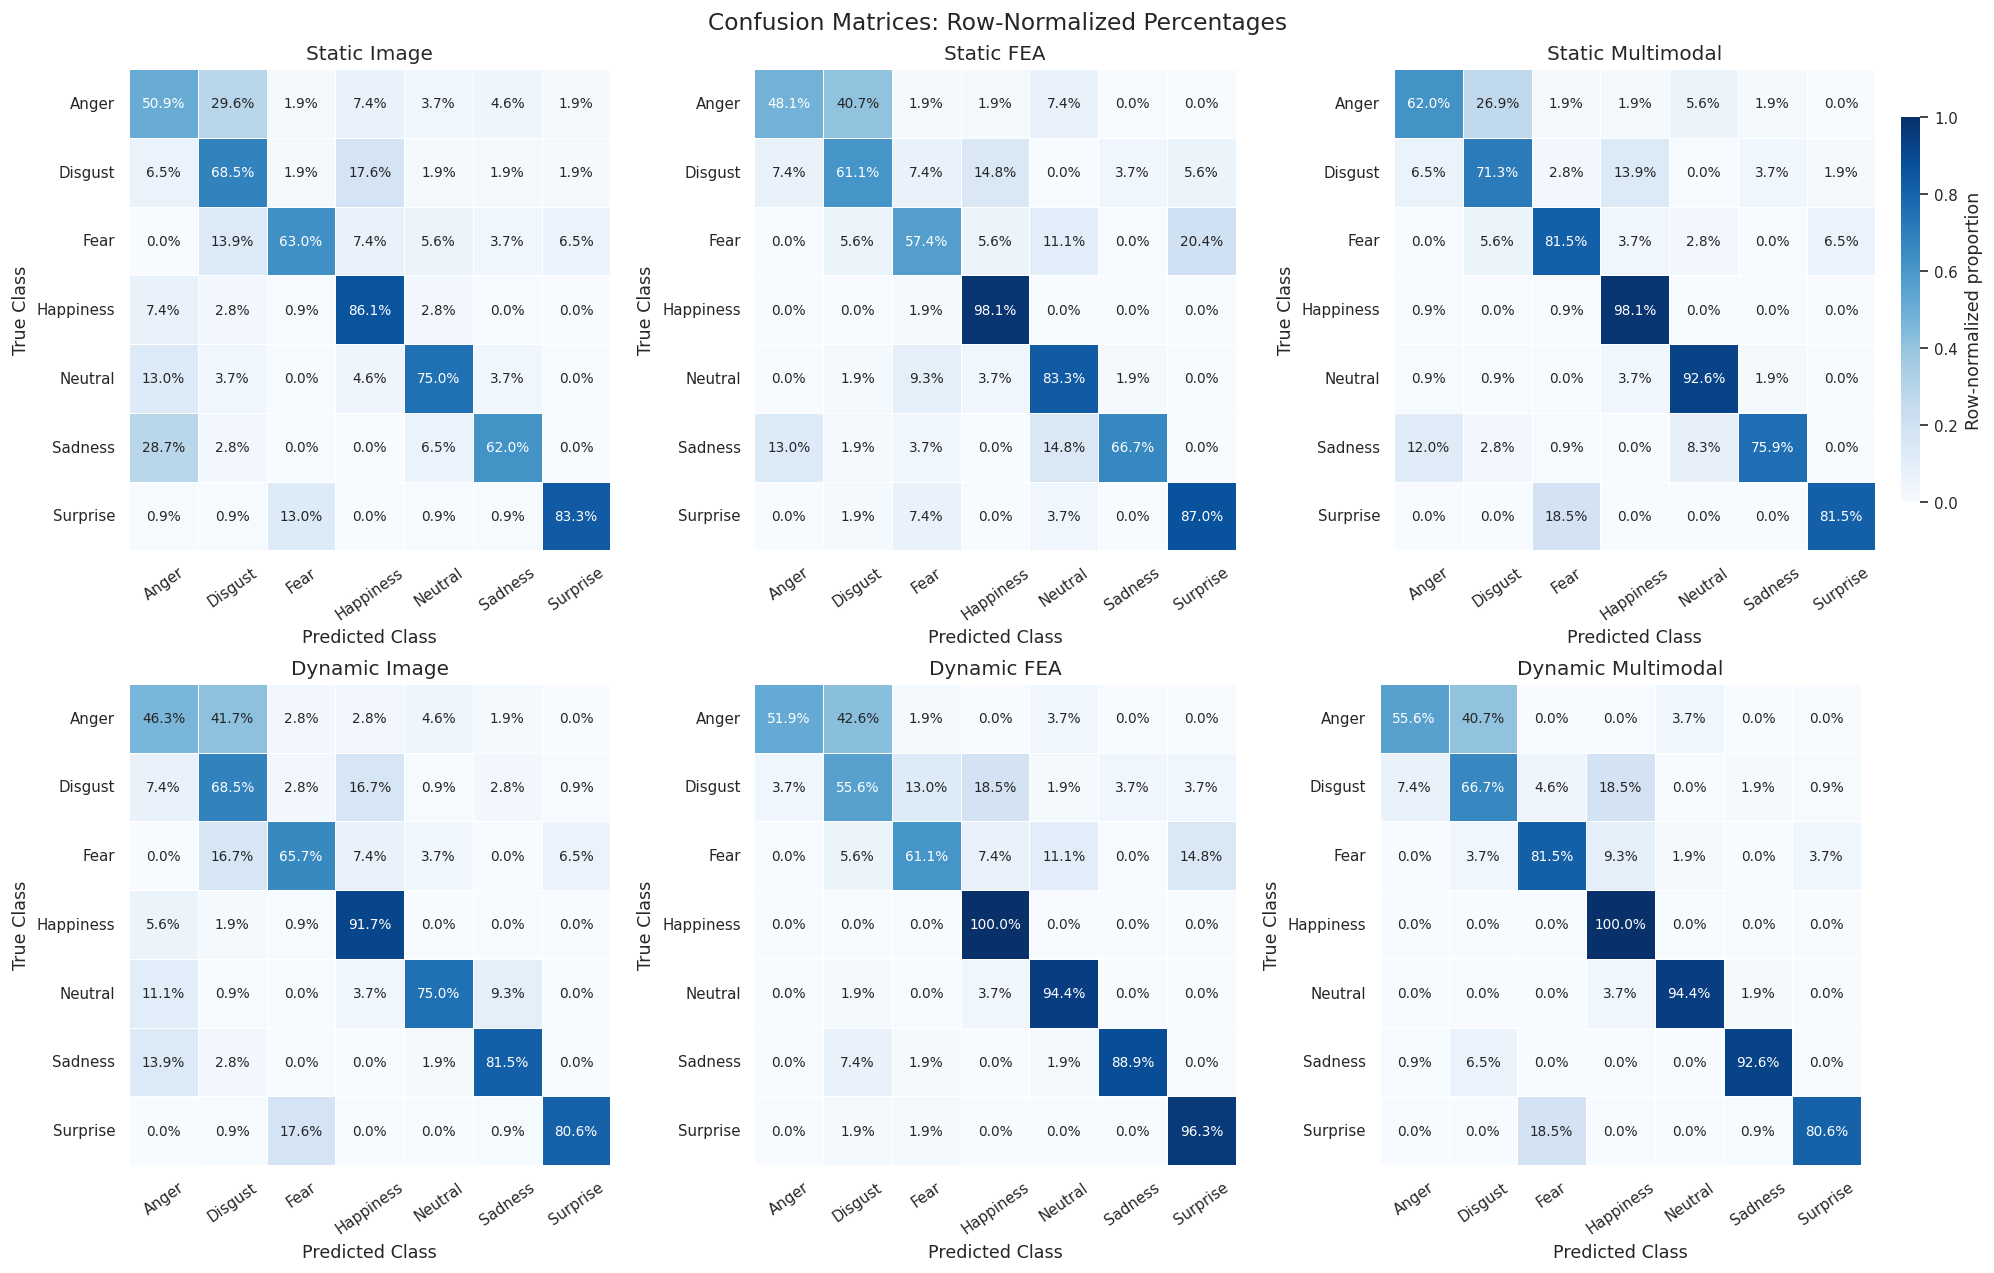

In [6]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16.5, 10.5),
    layout="constrained",
)

for row, setting_name in enumerate(["Static", "Dynamic"]):
    for col, modality in enumerate(MODALITIES):
        ax = axes[row, col]
        cm = confusion_cache[(setting_name, modality)].astype(float)
        cm_norm = cm / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm,
            annot=True,
            fmt=".1%",
            cmap="Blues",
            vmin=0,
            vmax=1,
            square=True,
            linewidths=0.6,
            linecolor="white",
            cbar=(row == 0 and col == 2),
            cbar_kws={"label": "Row-normalized proportion", "shrink": 0.8},
            xticklabels=CLASSES,
            yticklabels=CLASSES,
            annot_kws={"fontsize": 8.2},
            ax=ax,
        )

        ax.set_title(f"{setting_name} {DISPLAY[modality]}")
        ax.set_xlabel("Predicted Class")
        ax.set_ylabel("True Class")
        ax.tick_params(axis="x", rotation=35)
        ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Confusion Matrices: Row-Normalized Percentages",
    fontsize=14,
)

finish_figure(fig, "02_confusion_matrices_normalized")


### 3.1 Delta confusion matrices: Dynamic − Static

For each modality, the delta matrix is computed cell-by-cell as **Dynamic − Static**.

Two views are provided:

- **Count delta:** exact change in the number of predictions assigned to each confusion-matrix cell. This is valid within a modality because Static and Dynamic use the same analysis units.
- **Row-normalized delta:** change in the row-normalized confusion matrix, reported in **percentage points (pp)**. This is usually the more interpretable publication view.

A positive diagonal value means that Dynamic FER correctly classifies more samples of that class. For off-diagonal cells, a positive value means that the corresponding error became more frequent dynamically; a negative value means that error became less frequent.


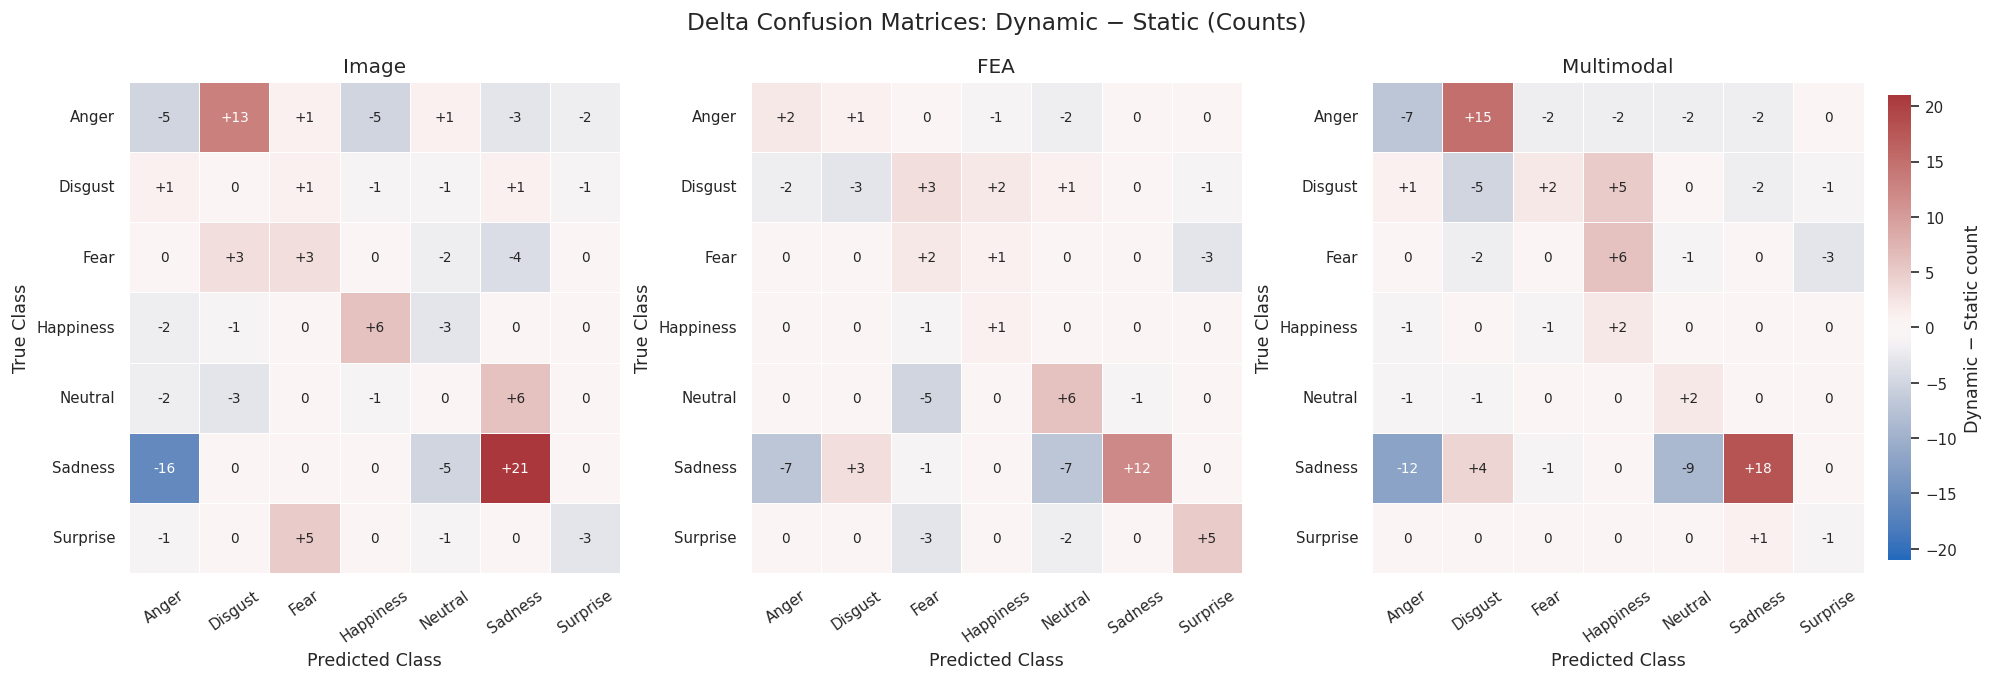

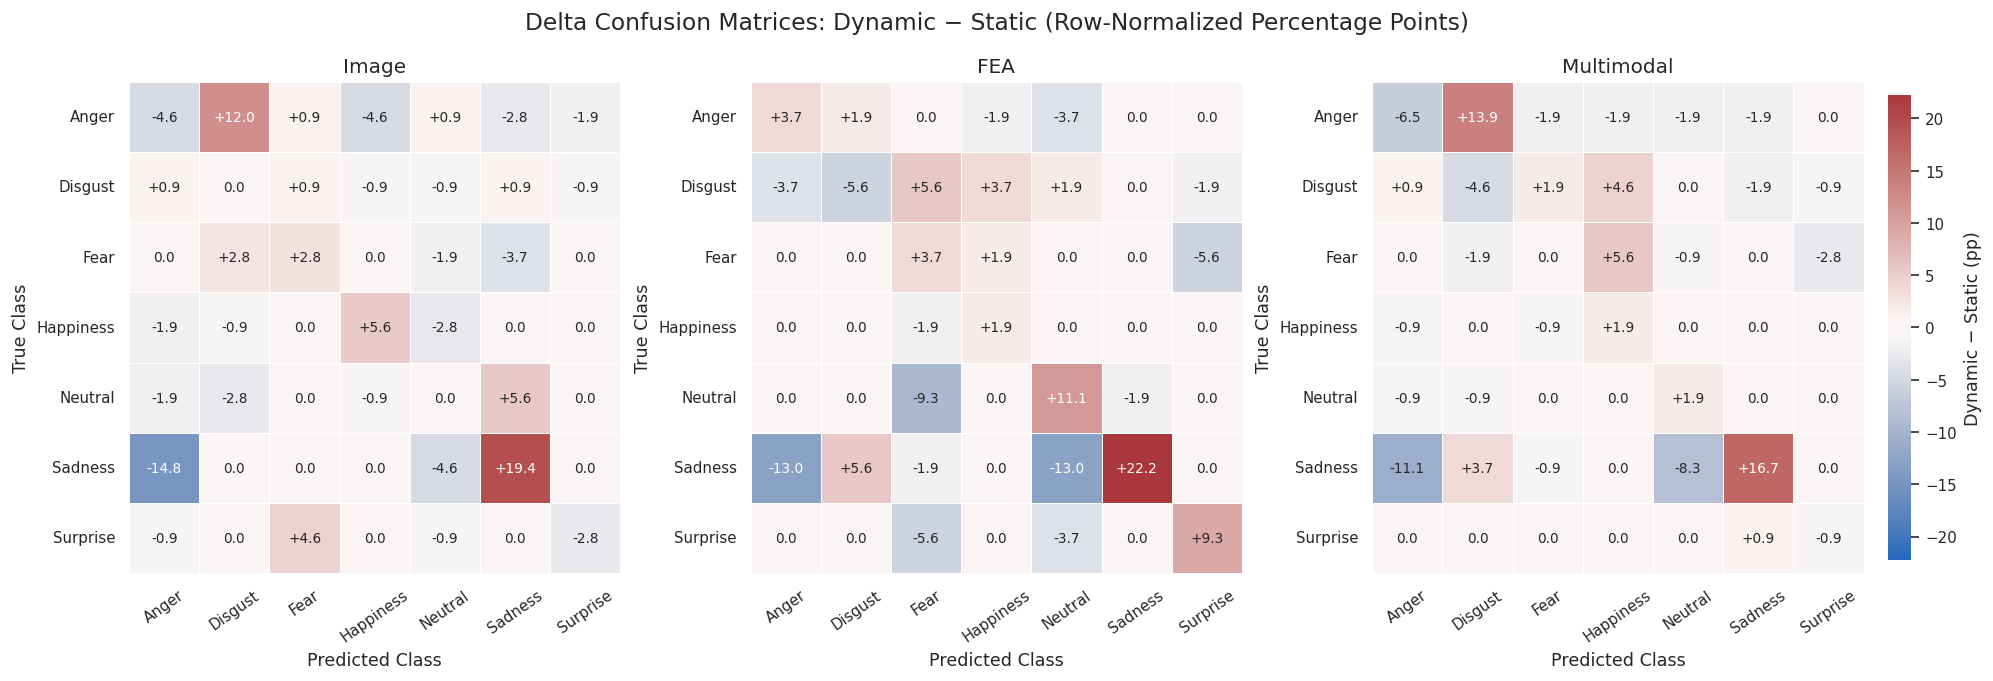

In [7]:
static_dynamic_delta_records = []
static_dynamic_delta_counts = {}
static_dynamic_delta_pp = {}

for modality in MODALITIES:
    static_cm = confusion_cache[("Static", modality)].astype(float)
    dynamic_cm = confusion_cache[("Dynamic", modality)].astype(float)

    delta_count = dynamic_cm - static_cm

    static_norm = static_cm / static_cm.sum(axis=1, keepdims=True)
    dynamic_norm = dynamic_cm / dynamic_cm.sum(axis=1, keepdims=True)
    delta_pp = 100 * (dynamic_norm - static_norm)

    static_dynamic_delta_counts[modality] = delta_count
    static_dynamic_delta_pp[modality] = delta_pp

    for i, true_class in enumerate(CLASSES):
        for j, predicted_class in enumerate(CLASSES):
            static_dynamic_delta_records.append({
                "modality": DISPLAY[modality],
                "true_class": true_class,
                "predicted_class": predicted_class,
                "static_count": int(static_cm[i, j]),
                "dynamic_count": int(dynamic_cm[i, j]),
                "delta_count": int(delta_count[i, j]),
                "static_row_pct": 100 * static_norm[i, j],
                "dynamic_row_pct": 100 * dynamic_norm[i, j],
                "delta_row_pp": delta_pp[i, j],
            })

static_dynamic_confusion_delta = pd.DataFrame(static_dynamic_delta_records)

# Exact count deltas.
max_abs_count = max(
    np.abs(matrix).max()
    for matrix in static_dynamic_delta_counts.values()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16.5, 5.6),
    layout="constrained",
)

for ax, modality in zip(axes, MODALITIES):
    matrix = static_dynamic_delta_counts[modality]
    annotations = np.vectorize(lambda x: "0" if x == 0 else f"{x:+.0f}")(matrix)

    sns.heatmap(
        matrix,
        annot=annotations,
        fmt="",
        cmap="vlag",
        center=0,
        vmin=-max_abs_count,
        vmax=max_abs_count,
        square=True,
        linewidths=0.6,
        linecolor="white",
        cbar=(modality == MODALITIES[-1]),
        cbar_kws={"label": "Dynamic − Static count", "shrink": 0.82},
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        annot_kws={"fontsize": 8.2},
        ax=ax,
    )

    ax.set_title(DISPLAY[modality])
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Delta Confusion Matrices: Dynamic − Static (Counts)",
    fontsize=14,
)

finish_figure(fig, "10_static_dynamic_confusion_delta_counts")

# Row-normalized percentage-point deltas.
max_abs_pp = max(
    np.abs(matrix).max()
    for matrix in static_dynamic_delta_pp.values()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16.5, 5.6),
    layout="constrained",
)

for ax, modality in zip(axes, MODALITIES):
    matrix = static_dynamic_delta_pp[modality]
    annotations = np.vectorize(lambda x: "0.0" if np.isclose(x, 0) else f"{x:+.1f}")(matrix)

    sns.heatmap(
        matrix,
        annot=annotations,
        fmt="",
        cmap="vlag",
        center=0,
        vmin=-max_abs_pp,
        vmax=max_abs_pp,
        square=True,
        linewidths=0.6,
        linecolor="white",
        cbar=(modality == MODALITIES[-1]),
        cbar_kws={"label": "Dynamic − Static (pp)", "shrink": 0.82},
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        annot_kws={"fontsize": 8.2},
        ax=ax,
    )

    ax.set_title(DISPLAY[modality])
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Delta Confusion Matrices: Dynamic − Static (Row-Normalized Percentage Points)",
    fontsize=14,
)

finish_figure(fig, "11_static_dynamic_confusion_delta_normalized")


## 4. Static → Dynamic comparison

### 4.1 Overall level

In [8]:
static_dynamic_overall = []

performance_indexed = performance.set_index(["setting", "modality"])

for modality in MODALITIES:
    modality_name = DISPLAY[modality]

    s, key, unit_name = modality_unit(static, modality)
    d, _, _ = modality_unit(dynamic, modality)

    s = add_correctness(s, modality, "static_correct")
    d = add_correctness(d, modality, "dynamic_correct")

    merged = s[
        [key, "true_label_id", "true_label", f"{modality}_pred_id", f"{modality}_pred", "static_correct"]
    ].merge(
        d[
            [key, f"{modality}_pred_id", f"{modality}_pred", "dynamic_correct"]
        ],
        on=key,
        suffixes=("_static", "_dynamic"),
        validate="one_to_one",
    )

    both_correct = merged["static_correct"] & merged["dynamic_correct"]
    static_only = merged["static_correct"] & ~merged["dynamic_correct"]
    dynamic_only = ~merged["static_correct"] & merged["dynamic_correct"]
    both_wrong = ~merged["static_correct"] & ~merged["dynamic_correct"]

    static_macro_f1 = performance_indexed.loc[("Static", modality_name), "macro_f1"]
    dynamic_macro_f1 = performance_indexed.loc[("Dynamic", modality_name), "macro_f1"]

    static_dynamic_overall.append({
        "modality": modality_name,
        "analysis_unit": unit_name,
        "n": len(merged),
        "static_accuracy": merged["static_correct"].mean(),
        "dynamic_accuracy": merged["dynamic_correct"].mean(),
        "delta_accuracy_pp": 100 * (
            merged["dynamic_correct"].mean() - merged["static_correct"].mean()
        ),
        "static_macro_f1": static_macro_f1,
        "dynamic_macro_f1": dynamic_macro_f1,
        "delta_macro_f1_pp": 100 * (dynamic_macro_f1 - static_macro_f1),
        "both_correct": int(both_correct.sum()),
        "static_only_correct": int(static_only.sum()),
        "dynamic_only_correct": int(dynamic_only.sum()),
        "both_wrong": int(both_wrong.sum()),
        "net_correct": int(dynamic_only.sum() - static_only.sum()),
    })

static_dynamic_overall = pd.DataFrame(static_dynamic_overall)
static_dynamic_overall


,modality,analysis_unit,n,static_accuracy,dynamic_accuracy,delta_accuracy_pp,static_macro_f1,dynamic_macro_f1,delta_macro_f1_pp,both_correct,static_only_correct,dynamic_only_correct,both_wrong,net_correct
0,Image,view sample,756,0.698413,0.727513,2.910053,0.700561,0.728686,2.812498,452,76,98,130,22
1,FEA,reenactment,378,0.716931,0.783069,6.613757,0.711015,0.777410,6.639545,255,16,41,66,25
2,Multimodal,view sample,756,0.804233,0.816138,1.190476,0.802249,0.814932,1.268265,552,56,65,83,9


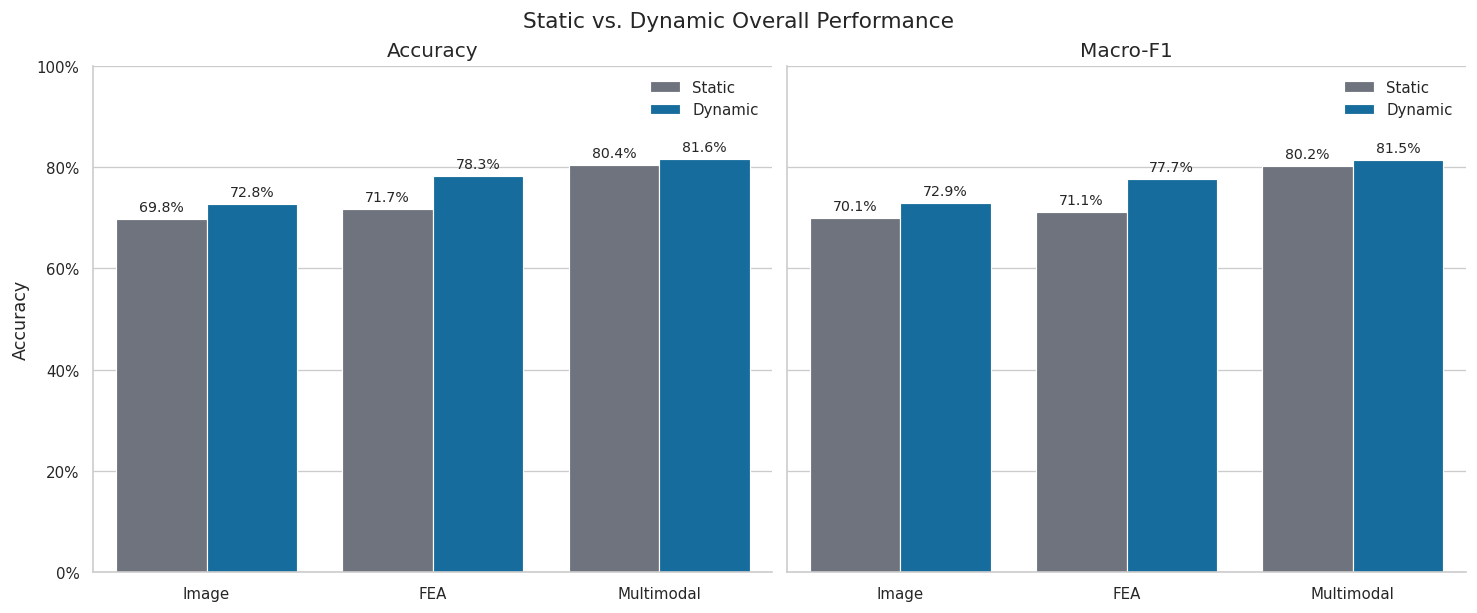

In [9]:
overall_plot = static_dynamic_overall[
    [
        "modality",
        "static_accuracy",
        "dynamic_accuracy",
        "static_macro_f1",
        "dynamic_macro_f1",
    ]
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.0), sharey=True, layout="constrained")

for ax, metric, static_col, dynamic_col in [
    (axes[0], "Accuracy", "static_accuracy", "dynamic_accuracy"),
    (axes[1], "Macro-F1", "static_macro_f1", "dynamic_macro_f1"),
]:
    plot_data = overall_plot[["modality", static_col, dynamic_col]].melt(
        id_vars="modality",
        var_name="setting",
        value_name="score",
    )
    plot_data["setting"] = plot_data["setting"].map({
        static_col: "Static",
        dynamic_col: "Dynamic",
    })

    sns.barplot(
        data=plot_data,
        x="modality",
        y="score",
        hue="setting",
        hue_order=["Static", "Dynamic"],
        palette={"Static": STATIC_COLOR, "Dynamic": DYNAMIC_COLOR},
        edgecolor="white",
        linewidth=0.7,
        ax=ax,
    )

    ax.set(
        xlabel="",
        ylabel=metric if ax is axes[0] else "",
        ylim=(0, 1),
        title=metric,
    )
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(title="", frameon=False)
    add_bar_labels(ax)
    sns.despine(ax=ax)

fig.suptitle("Static vs. Dynamic Overall Performance", fontsize=13)

finish_figure(fig, "03_static_dynamic_overall_accuracy")


### 4.2 Class level

In [10]:
static_dynamic_class_transitions = []

for modality in MODALITIES:
    s, key, unit_name = modality_unit(static, modality)
    d, _, _ = modality_unit(dynamic, modality)

    s = add_correctness(s, modality, "static_correct")
    d = add_correctness(d, modality, "dynamic_correct")

    merged = s[
        [key, "true_label_id", "true_label", "static_correct"]
    ].merge(
        d[[key, "dynamic_correct"]],
        on=key,
        validate="one_to_one",
    )

    for class_id, class_name in enumerate(CLASSES):
        g = merged[merged["true_label_id"] == class_id]

        static_dynamic_class_transitions.append({
            "modality": DISPLAY[modality],
            "class": class_name,
            "n": len(g),
            "both_correct": int((g["static_correct"] & g["dynamic_correct"]).sum()),
            "static_only_correct": int((g["static_correct"] & ~g["dynamic_correct"]).sum()),
            "dynamic_only_correct": int((~g["static_correct"] & g["dynamic_correct"]).sum()),
            "both_wrong": int((~g["static_correct"] & ~g["dynamic_correct"]).sum()),
        })

class_transitions = pd.DataFrame(static_dynamic_class_transitions)

static_class = (
    class_metrics[class_metrics["setting"] == "Static"]
    .drop(columns="setting")
    .rename(columns={
        "support": "static_support",
        "precision": "static_precision",
        "recall": "static_recall",
        "f1": "static_f1",
    })
)

dynamic_class = (
    class_metrics[class_metrics["setting"] == "Dynamic"]
    .drop(columns="setting")
    .rename(columns={
        "support": "dynamic_support",
        "precision": "dynamic_precision",
        "recall": "dynamic_recall",
        "f1": "dynamic_f1",
    })
)

static_dynamic_class_comparison = static_class.merge(
    dynamic_class,
    on=["modality", "class"],
    validate="one_to_one",
)

for metric in ["precision", "recall", "f1"]:
    static_dynamic_class_comparison[f"delta_{metric}_pp"] = 100 * (
        static_dynamic_class_comparison[f"dynamic_{metric}"]
        - static_dynamic_class_comparison[f"static_{metric}"]
    )

static_dynamic_class_comparison = static_dynamic_class_comparison.merge(
    class_transitions,
    on=["modality", "class"],
    validate="one_to_one",
)

class_recall = static_dynamic_class_comparison[
    [
        "modality", "class", "dynamic_support",
        "static_recall", "dynamic_recall", "delta_recall_pp"
    ]
].rename(columns={
    "dynamic_support": "n",
    "delta_recall_pp": "delta_pp",
})

static_dynamic_class_comparison.to_csv(
    TABLE_DIR / "static_dynamic_class_comparison.csv",
    index=False,
)

static_dynamic_class_comparison


,modality,class,static_support,static_precision,static_recall,static_f1,dynamic_support,dynamic_precision,dynamic_recall,dynamic_f1,delta_precision_pp,delta_recall_pp,delta_f1_pp,n,both_correct,static_only_correct,dynamic_only_correct,both_wrong
0,Image,Anger,108,0.474138,0.509259,0.491071,108,0.549451,0.462963,0.502513,7.531262,-4.629630,1.144113,108,38,17,12,41
1,Image,Disgust,108,0.560606,0.685185,0.616667,108,0.513889,0.685185,0.587302,-4.671717,0.000000,-2.936508,108,61,13,13,21
2,Image,Fear,108,0.781609,0.629630,0.697436,108,0.731959,0.657407,0.692683,-4.965043,2.777778,-0.475297,108,50,18,21,19
3,Image,Happiness,108,0.699248,0.861111,0.771784,108,0.750000,0.916667,0.825000,5.075188,5.555556,5.321577,108,89,4,10,5
4,Image,Neutral,108,0.778846,0.750000,0.764151,108,0.870968,0.750000,0.805970,9.212159,0.000000,4.181921,108,72,9,9,18
5,Image,Sadness,108,0.807229,0.620370,0.701571,108,0.846154,0.814815,0.830189,3.892493,19.444444,12.861800,108,61,6,27,14
6,Image,Surprise,108,0.891089,0.833333,0.861244,108,0.915789,0.805556,0.857143,2.470036,-2.777778,-0.410116,108,81,9,6,12
7,FEA,Anger,54,0.702703,0.481481,0.571429,54,0.933333,0.518519,0.666667,23.063063,3.703704,9.523810,54,23,3,5,23
8,FEA,Disgust,54,0.540984,0.611111,0.573913,54,0.483871,0.555556,0.517241,-5.711264,-5.555556,-5.667166,54,27,6,3,18
9,FEA,Fear,54,0.645833,0.574074,0.607843,54,0.767442,0.611111,0.680412,12.160853,3.703704,7.256923,54,25,6,8,15


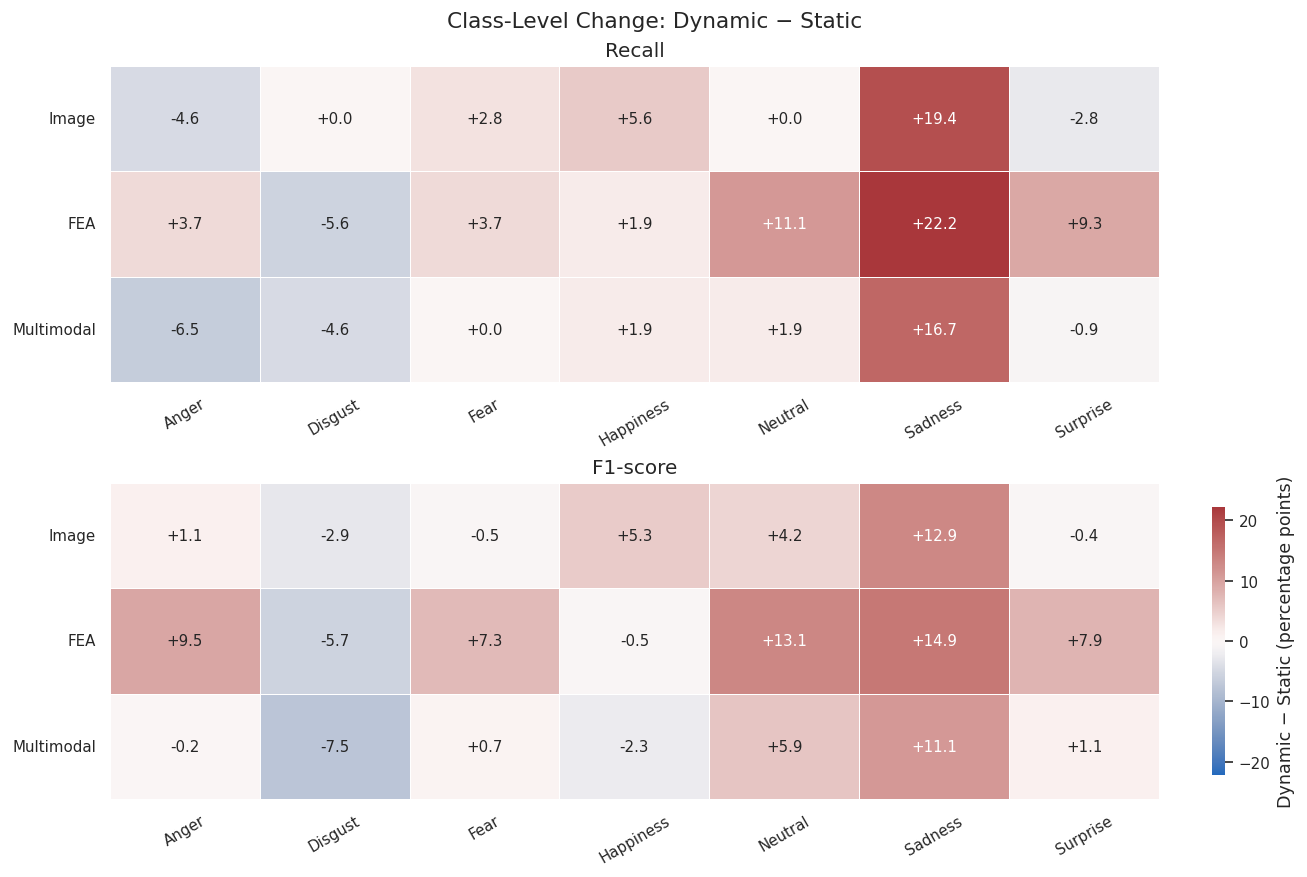

In [11]:
recall_delta_matrix = (
    static_dynamic_class_comparison
    .pivot(index="modality", columns="class", values="delta_recall_pp")
    .reindex(index=[DISPLAY[m] for m in MODALITIES], columns=CLASSES)
)

f1_delta_matrix = (
    static_dynamic_class_comparison
    .pivot(index="modality", columns="class", values="delta_f1_pp")
    .reindex(index=[DISPLAY[m] for m in MODALITIES], columns=CLASSES)
)

max_abs = float(max(
    np.abs(recall_delta_matrix.to_numpy()).max(),
    np.abs(f1_delta_matrix.to_numpy()).max(),
))

fig, axes = plt.subplots(2, 1, figsize=(10.8, 7.2), layout="constrained")

for ax, matrix, title in [
    (axes[0], recall_delta_matrix, "Recall"),
    (axes[1], f1_delta_matrix, "F1-score"),
]:
    sns.heatmap(
        matrix,
        annot=True,
        fmt="+.1f",
        cmap="vlag",
        center=0,
        vmin=-max_abs,
        vmax=max_abs,
        linewidths=0.6,
        linecolor="white",
        cbar=(ax is axes[1]),
        cbar_kws={"label": "Dynamic − Static (percentage points)", "shrink": 0.85},
        annot_kws={"fontsize": 9},
        ax=ax,
    )
    ax.set(
        xlabel="",
        ylabel="",
        title=title,
    )
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Class-Level Change: Dynamic − Static", fontsize=13)

finish_figure(fig, "04_static_dynamic_class_recall_delta")


### 4.3 Sample-level prediction overlap

For each modality, the heatmap compares Static and Dynamic predictions class by class. Columns are true emotion classes; the four rows separate samples into **both correct**, **only Dynamic correct**, **only Static correct**, and **both incorrect**.

Each cell reports the absolute count and the percentage within that true class. The color scale is fixed to **0–100% across all panels** so that equal shades have the same meaning in every comparison.


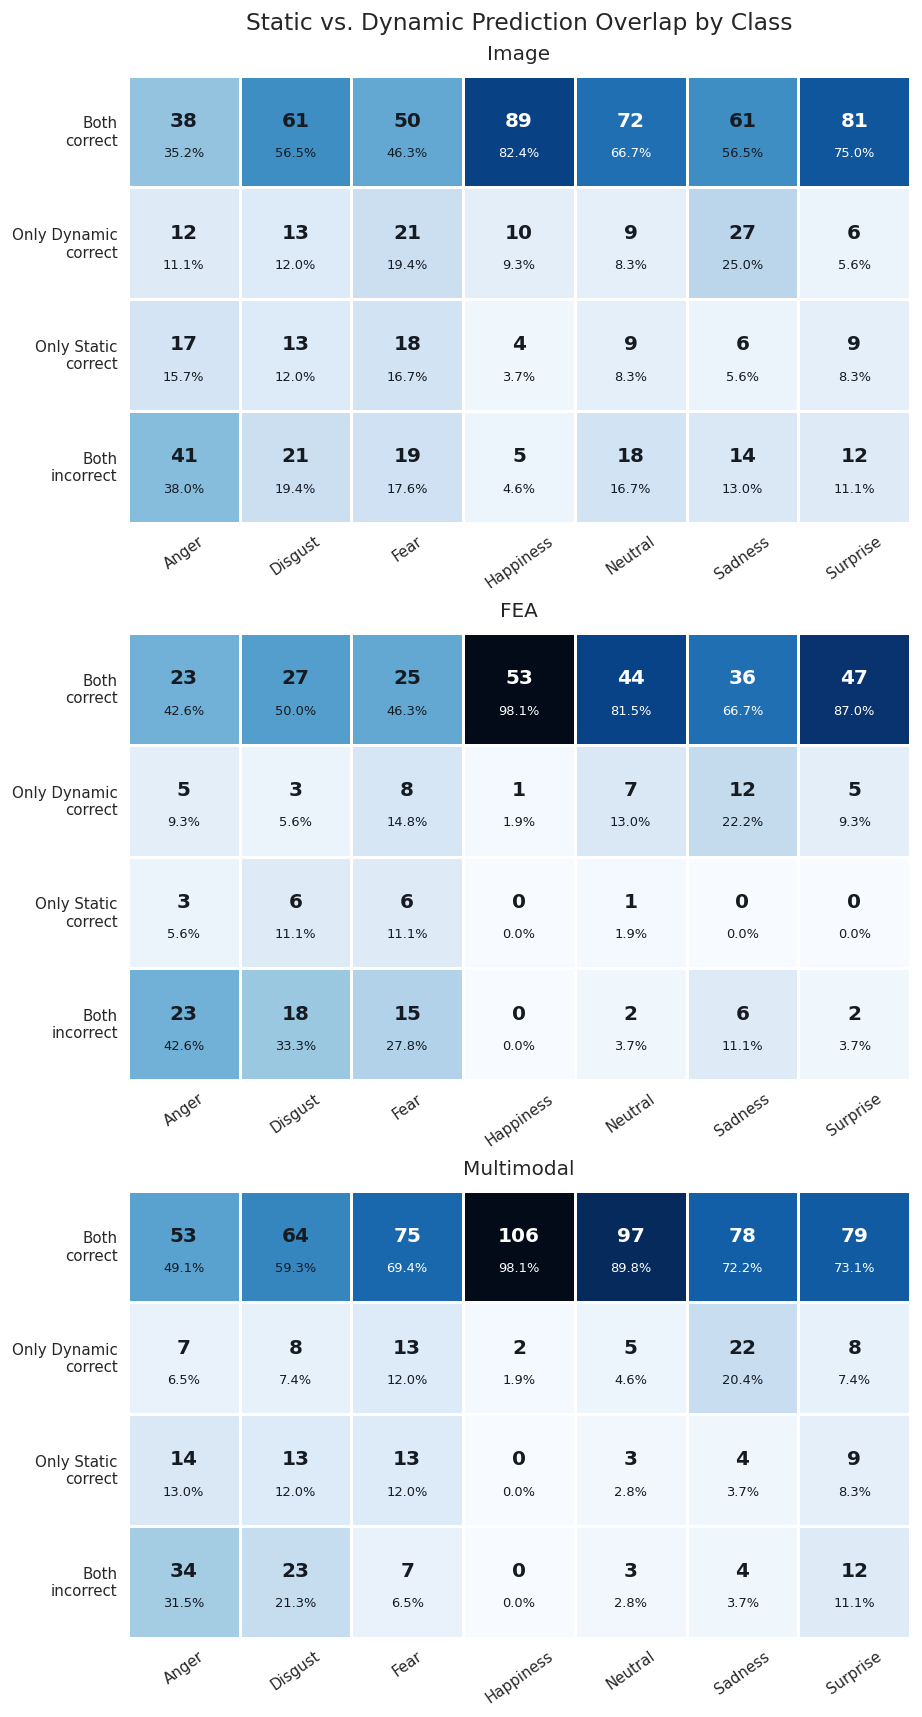

In [12]:
sample_transition_exports = []
static_dynamic_overlap_records = []
static_dynamic_overlap_counts = {}

for modality in MODALITIES:
    s, key, unit_name = modality_unit(static, modality)
    d, _, _ = modality_unit(dynamic, modality)

    s = add_correctness(s, modality, "static_correct")
    d = add_correctness(d, modality, "dynamic_correct")

    keep_s = [
        key, "participant_id", "true_label_id", "true_label",
        f"{modality}_pred_id", f"{modality}_pred", "static_correct"
    ]
    if key == "sample_id":
        keep_s += ["reenactment_id", "perspective"]

    merged = s[keep_s].merge(
        d[[key, f"{modality}_pred_id", f"{modality}_pred", "dynamic_correct"]],
        on=key,
        suffixes=("_static", "_dynamic"),
        validate="one_to_one",
    )

    conditions = [
        merged["static_correct"] & merged["dynamic_correct"],
        merged["static_correct"] & ~merged["dynamic_correct"],
        ~merged["static_correct"] & merged["dynamic_correct"],
        ~merged["static_correct"] & ~merged["dynamic_correct"],
    ]
    labels = ["both_correct", "static_only_correct", "dynamic_only_correct", "both_wrong"]
    merged["transition"] = np.select(conditions, labels, default="unclassified")

    merged.insert(0, "modality", DISPLAY[modality])
    sample_transition_exports.append(merged)

    counts = overlap_counts_by_class(
        merged,
        first_correct_col="static_correct",
        second_correct_col="dynamic_correct",
    )
    static_dynamic_overlap_counts[modality] = counts
    percentages = 100 * counts / counts.sum(axis=0, keepdims=True)

    overlap_names = [
        "both_correct",
        "dynamic_only_correct",
        "static_only_correct",
        "both_incorrect",
    ]
    for row, outcome in enumerate(overlap_names):
        for col, class_name in enumerate(CLASSES):
            static_dynamic_overlap_records.append({
                "modality": DISPLAY[modality],
                "outcome": outcome,
                "class": class_name,
                "count": int(counts[row, col]),
                "class_percentage": float(percentages[row, col]),
                "analysis_unit": unit_name,
            })

sample_transitions = pd.concat(sample_transition_exports, ignore_index=True)
sample_transitions.to_csv(
    TABLE_DIR / "static_dynamic_sample_transitions.csv",
    index=False,
)

static_dynamic_overlap = pd.DataFrame(static_dynamic_overlap_records)

row_labels = [
    "Both\ncorrect",
    "Only Dynamic\ncorrect",
    "Only Static\ncorrect",
    "Both\nincorrect",
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10.8, 14.2),
    layout="constrained",
)

for ax, modality in zip(axes, MODALITIES):
    draw_overlap_heatmap(
        ax,
        static_dynamic_overlap_counts[modality],
        row_labels=row_labels,
        title=DISPLAY[modality],
    )

fig.suptitle(
    "Static vs. Dynamic Prediction Overlap by Class",
    fontsize=14,
)

finish_figure(fig, "05_static_dynamic_prediction_overlap")


## 5. Error-pair changes from Static to Dynamic

In [13]:
error_pair_records = []
error_change_records = []

for modality in MODALITIES:
    for setting_name in ["Static", "Dynamic"]:
        cm = confusion_cache[(setting_name, modality)]

        for i, true_class in enumerate(CLASSES):
            for j, predicted_class in enumerate(CLASSES):
                if i == j:
                    continue
                error_pair_records.append({
                    "setting": setting_name,
                    "modality": DISPLAY[modality],
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "count": int(cm[i, j]),
                })

    static_cm = confusion_cache[("Static", modality)]
    dynamic_cm = confusion_cache[("Dynamic", modality)]

    for i, true_class in enumerate(CLASSES):
        for j, predicted_class in enumerate(CLASSES):
            if i == j:
                continue

            error_change_records.append({
                "modality": DISPLAY[modality],
                "true_class": true_class,
                "predicted_class": predicted_class,
                "static_count": int(static_cm[i, j]),
                "dynamic_count": int(dynamic_cm[i, j]),
                "delta_count": int(dynamic_cm[i, j] - static_cm[i, j]),
            })

error_pairs = pd.DataFrame(error_pair_records)
error_changes = pd.DataFrame(error_change_records)


top_dynamic_errors = (
    error_pairs[error_pairs["setting"] == "Dynamic"]
    .sort_values(["modality", "count"], ascending=[True, False])
    .groupby("modality", group_keys=False)
    .head(8)
)

top_dynamic_errors


,setting,modality,true_class,predicted_class,count
126,Dynamic,FEA,Anger,Disgust,23
134,Dynamic,FEA,Disgust,Happiness,10
143,Dynamic,FEA,Fear,Surprise,8
133,Dynamic,FEA,Disgust,Fear,7
141,Dynamic,FEA,Fear,Neutral,6
140,Dynamic,FEA,Fear,Happiness,4
157,Dynamic,FEA,Sadness,Disgust,4
139,Dynamic,FEA,Fear,Disgust,3
42,Dynamic,Image,Anger,Disgust,45
80,Dynamic,Image,Surprise,Fear,19


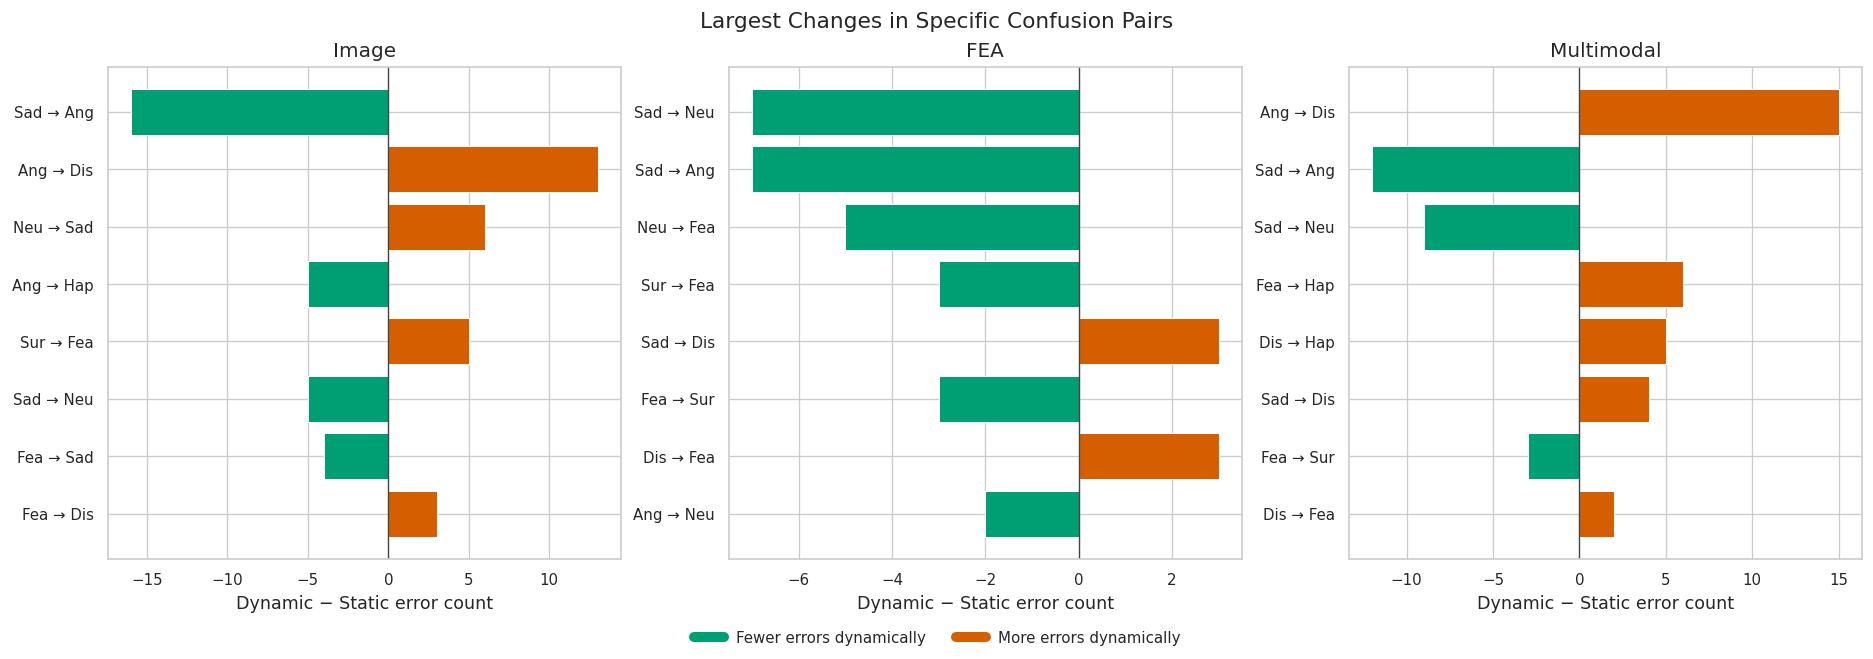

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4), layout="constrained")

for ax, modality in zip(axes, [DISPLAY[m] for m in MODALITIES]):
    g = error_changes[error_changes["modality"] == modality].copy()
    g["abs_delta"] = g["delta_count"].abs()
    g = g.sort_values("abs_delta", ascending=False).head(8)
    labels = g["true_class"].str[:3] + " → " + g["predicted_class"].str[:3]
    colors = [
        NEGATIVE_COLOR if value > 0 else POSITIVE_COLOR
        for value in g["delta_count"]
    ]

    ax.barh(
        np.arange(len(g)),
        g["delta_count"],
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_yticks(np.arange(len(g)), labels)
    ax.axvline(0, color="#444444", linewidth=0.8)
    ax.set_title(modality)
    ax.set_xlabel("Dynamic − Static error count")
    ax.invert_yaxis()

fig.suptitle("Largest Changes in Specific Confusion Pairs", fontsize=13)

legend_handles = [
    plt.Line2D([0], [0], color=POSITIVE_COLOR, lw=6, label="Fewer errors dynamically"),
    plt.Line2D([0], [0], color=NEGATIVE_COLOR, lw=6, label="More errors dynamically"),
]
fig.legend(
    handles=legend_handles,
    loc="outside lower center",
    ncol=2,
    frameon=False,
)

finish_figure(fig, "06_static_dynamic_error_pair_changes")


## 6. Comparisons within the Dynamic setting

All three dynamic modalities are shown. Cross-modality sample-level comparisons use the 756 aligned view rows. Therefore, in comparisons involving FEA, each reenactment-level FEA decision occurs twice (once for Central and once for Side). These are descriptive paired view-row comparisons, not 756 independent FEA observations.

In [15]:
dynamic_accuracy = (
    performance[performance["setting"] == "Dynamic"]
    .drop(columns="setting")
    .reset_index(drop=True)
)

dynamic_class_metrics = (
    class_metrics[class_metrics["setting"] == "Dynamic"]
    .drop(columns="setting")
    .reset_index(drop=True)
)

dynamic_class_recall = dynamic_class_metrics[
    ["modality", "class", "support", "recall"]
].rename(columns={"support": "n"})

dynamic_accuracy


,modality,analysis_unit,n,correct,accuracy,macro_precision,macro_recall,macro_f1
0,Image,view sample,756,550,0.727513,0.739744,0.727513,0.728686
1,FEA,reenactment,378,296,0.783069,0.798693,0.783069,0.777410
2,Multimodal,view sample,756,617,0.816138,0.831185,0.816138,0.814932


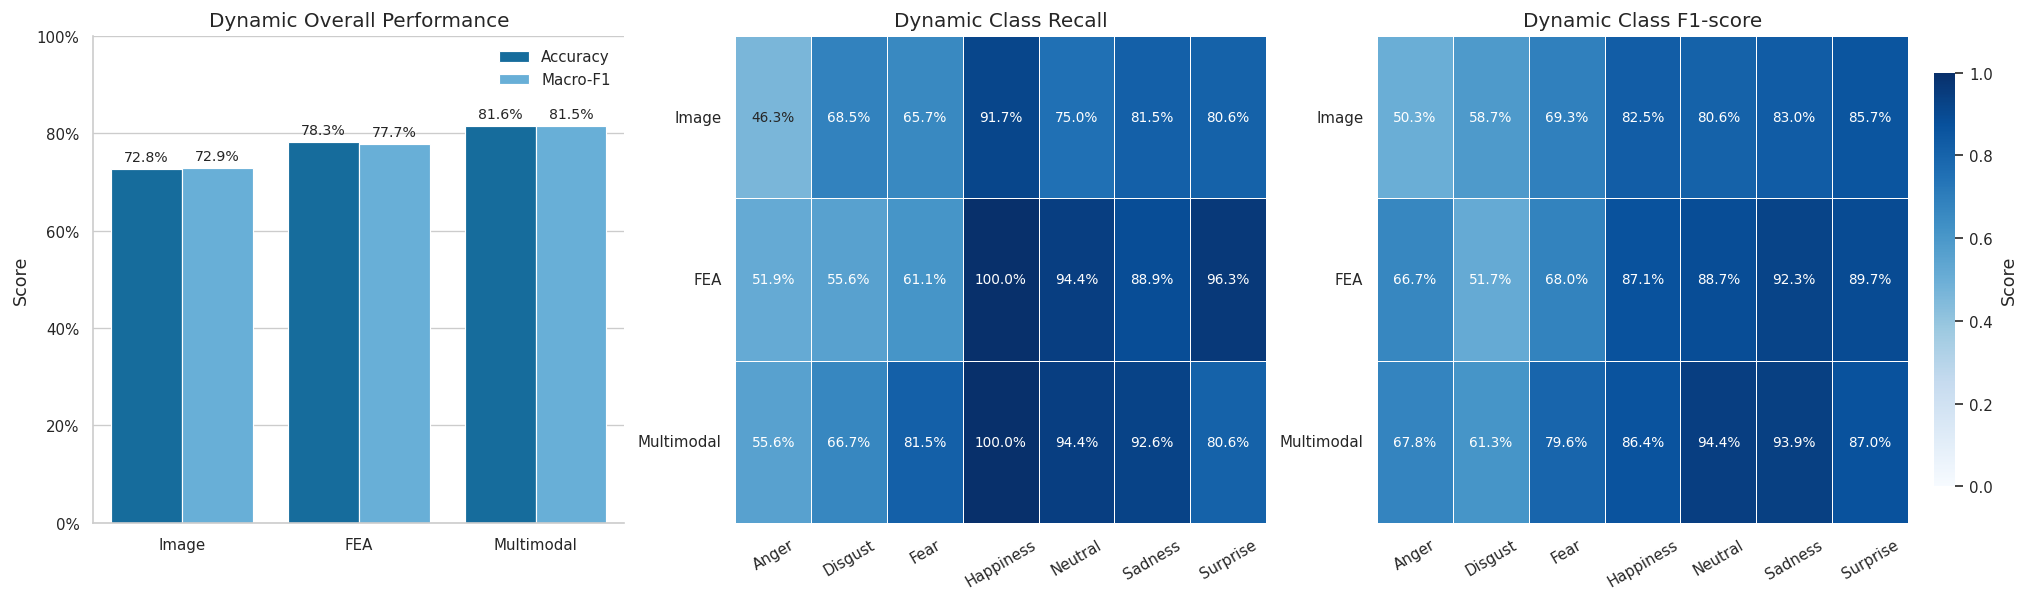

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16.8, 4.9), layout="constrained")

overall_dynamic_plot = dynamic_accuracy.melt(
    id_vars=["modality"],
    value_vars=["accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)
overall_dynamic_plot["metric"] = overall_dynamic_plot["metric"].map({
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
})

sns.barplot(
    data=overall_dynamic_plot,
    x="modality",
    y="score",
    hue="metric",
    hue_order=["Accuracy", "Macro-F1"],
    palette={"Accuracy": DYNAMIC_COLOR, "Macro-F1": "#56B4E9"},
    edgecolor="white",
    linewidth=0.7,
    ax=axes[0],
)
axes[0].set(
    xlabel="",
    ylabel="Score",
    ylim=(0, 1),
    title="Dynamic Overall Performance",
)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(title="", frameon=False)
add_bar_labels(axes[0])
sns.despine(ax=axes[0])

for ax, metric, title in [
    (axes[1], "recall", "Dynamic Class Recall"),
    (axes[2], "f1", "Dynamic Class F1-score"),
]:
    matrix = (
        dynamic_class_metrics
        .pivot(index="modality", columns="class", values=metric)
        .reindex(index=[DISPLAY[m] for m in MODALITIES], columns=CLASSES)
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.6,
        linecolor="white",
        cbar=(ax is axes[2]),
        cbar_kws={"label": "Score", "shrink": 0.85},
        annot_kws={"fontsize": 8.2},
        ax=ax,
    )
    ax.set(
        xlabel="",
        ylabel="",
        title=title,
    )
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

finish_figure(fig, "07_dynamic_modality_performance")


### 6.1 Pairwise dynamic comparisons

The three pairwise Dynamic comparisons are analyzed on the aligned 756 view rows:

1. **Image vs. FEA** — useful directly for the Dynamic complementarity analysis.
2. **Image vs. Multimodal**
3. **FEA vs. Multimodal**

For comparisons involving FEA, the same reenactment-level FEA decision is associated with the Central and Side view rows. This is appropriate for descriptive overlap analysis with the view-specific models, but the duplicated FEA rows are not independent observations.


In [17]:
PAIRWISE = [
    ("image", "fea"),
    ("image", "multimodal"),
    ("fea", "multimodal"),
]

pairwise_overall_records = []
pairwise_class_records = []
pairwise_sample_records = []
pairwise_perspective_records = []

dynamic_aligned_class_metrics = {}

for modality in MODALITIES:
    y_true = dynamic["true_label_id"].to_numpy()
    y_pred = dynamic[f"{modality}_pred_id"].to_numpy()

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=CLASS_IDS,
        zero_division=0,
    )

    dynamic_aligned_class_metrics[modality] = pd.DataFrame({
        "class": CLASSES,
        "support": support.astype(int),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

for base, target in PAIRWISE:
    d = dynamic.copy()
    d["base_correct"] = d[f"{base}_pred_id"] == d["true_label_id"]
    d["target_correct"] = d[f"{target}_pred_id"] == d["true_label_id"]

    both_correct = d["base_correct"] & d["target_correct"]
    base_only = d["base_correct"] & ~d["target_correct"]
    target_only = ~d["base_correct"] & d["target_correct"]
    both_wrong = ~d["base_correct"] & ~d["target_correct"]

    pair_name = f"{DISPLAY[base]} → {DISPLAY[target]}"

    pairwise_overall_records.append({
        "comparison": pair_name,
        "n_view_rows": len(d),
        "base_accuracy": d["base_correct"].mean(),
        "target_accuracy": d["target_correct"].mean(),
        "delta_accuracy_pp": 100 * (
            d["target_correct"].mean() - d["base_correct"].mean()
        ),
        "both_correct": int(both_correct.sum()),
        "base_only_correct": int(base_only.sum()),
        "target_only_correct": int(target_only.sum()),
        "both_wrong": int(both_wrong.sum()),
        "net_correct": int(target_only.sum() - base_only.sum()),
        "base_error_rescue_rate": float(target_only.sum() / (~d["base_correct"]).sum()),
        "base_correct_retention_rate": float(both_correct.sum() / d["base_correct"].sum()),
        "same_predicted_class_rate": float(
            (d[f"{base}_pred_id"] == d[f"{target}_pred_id"]).mean()
        ),
    })

    transition = np.select(
        [both_correct, base_only, target_only, both_wrong],
        ["both_correct", "base_only_correct", "target_only_correct", "both_wrong"],
        default="unclassified",
    )

    sample_export = d[
        ["sample_id", "reenactment_id", "participant_id", "perspective", "true_label_id", "true_label"]
    ].copy()
    sample_export.insert(0, "comparison", pair_name)
    sample_export["base_prediction"] = d[f"{base}_pred"]
    sample_export["target_prediction"] = d[f"{target}_pred"]
    sample_export["base_correct"] = d["base_correct"]
    sample_export["target_correct"] = d["target_correct"]
    sample_export["transition"] = transition
    pairwise_sample_records.append(sample_export)

    base_metrics = dynamic_aligned_class_metrics[base].rename(columns={
        "support": "base_support",
        "precision": "base_precision",
        "recall": "base_recall",
        "f1": "base_f1",
    })
    target_metrics = dynamic_aligned_class_metrics[target].rename(columns={
        "support": "target_support",
        "precision": "target_precision",
        "recall": "target_recall",
        "f1": "target_f1",
    })

    metrics = base_metrics.merge(
        target_metrics,
        on="class",
        validate="one_to_one",
    )

    for _, metric_row in metrics.iterrows():
        class_name = metric_row["class"]
        class_id = CLASSES.index(class_name)
        g = d[d["true_label_id"] == class_id]

        pairwise_class_records.append({
            "comparison": pair_name,
            "class": class_name,
            "n_view_rows": len(g),
            "base_precision": metric_row["base_precision"],
            "target_precision": metric_row["target_precision"],
            "delta_precision_pp": 100 * (
                metric_row["target_precision"] - metric_row["base_precision"]
            ),
            "base_recall": metric_row["base_recall"],
            "target_recall": metric_row["target_recall"],
            "delta_recall_pp": 100 * (
                metric_row["target_recall"] - metric_row["base_recall"]
            ),
            "base_f1": metric_row["base_f1"],
            "target_f1": metric_row["target_f1"],
            "delta_f1_pp": 100 * (
                metric_row["target_f1"] - metric_row["base_f1"]
            ),
            "base_only_correct": int((g["base_correct"] & ~g["target_correct"]).sum()),
            "target_only_correct": int((~g["base_correct"] & g["target_correct"]).sum()),
            "both_wrong": int((~g["base_correct"] & ~g["target_correct"]).sum()),
        })

    for perspective, g in d.groupby("perspective"):
        pairwise_perspective_records.append({
            "comparison": pair_name,
            "perspective": perspective,
            "n": len(g),
            "base_accuracy": g["base_correct"].mean(),
            "target_accuracy": g["target_correct"].mean(),
            "delta_accuracy_pp": 100 * (
                g["target_correct"].mean() - g["base_correct"].mean()
            ),
            "base_only_correct": int((g["base_correct"] & ~g["target_correct"]).sum()),
            "target_only_correct": int((~g["base_correct"] & g["target_correct"]).sum()),
        })

pairwise_overall = pd.DataFrame(pairwise_overall_records)
pairwise_class = pd.DataFrame(pairwise_class_records)
pairwise_samples = pd.concat(pairwise_sample_records, ignore_index=True)
pairwise_perspective = pd.DataFrame(pairwise_perspective_records)

pairwise_class.to_csv(
    TABLE_DIR / "dynamic_pairwise_class_comparison.csv",
    index=False,
)
pairwise_samples.to_csv(
    TABLE_DIR / "dynamic_pairwise_sample_transitions.csv",
    index=False,
)

pairwise_overall


,comparison,n_view_rows,base_accuracy,target_accuracy,delta_accuracy_pp,both_correct,base_only_correct,target_only_correct,both_wrong,net_correct,base_error_rescue_rate,base_correct_retention_rate,same_predicted_class_rate
0,Image → FEA,756,0.727513,0.783069,5.555556,476,74,116,90,42,0.563107,0.865455,0.708995
1,Image → Multimodal,756,0.727513,0.816138,8.862434,526,24,91,115,67,0.441748,0.956364,0.822751
2,FEA → Multimodal,756,0.783069,0.816138,3.306878,560,32,57,107,25,0.347561,0.945946,0.871693


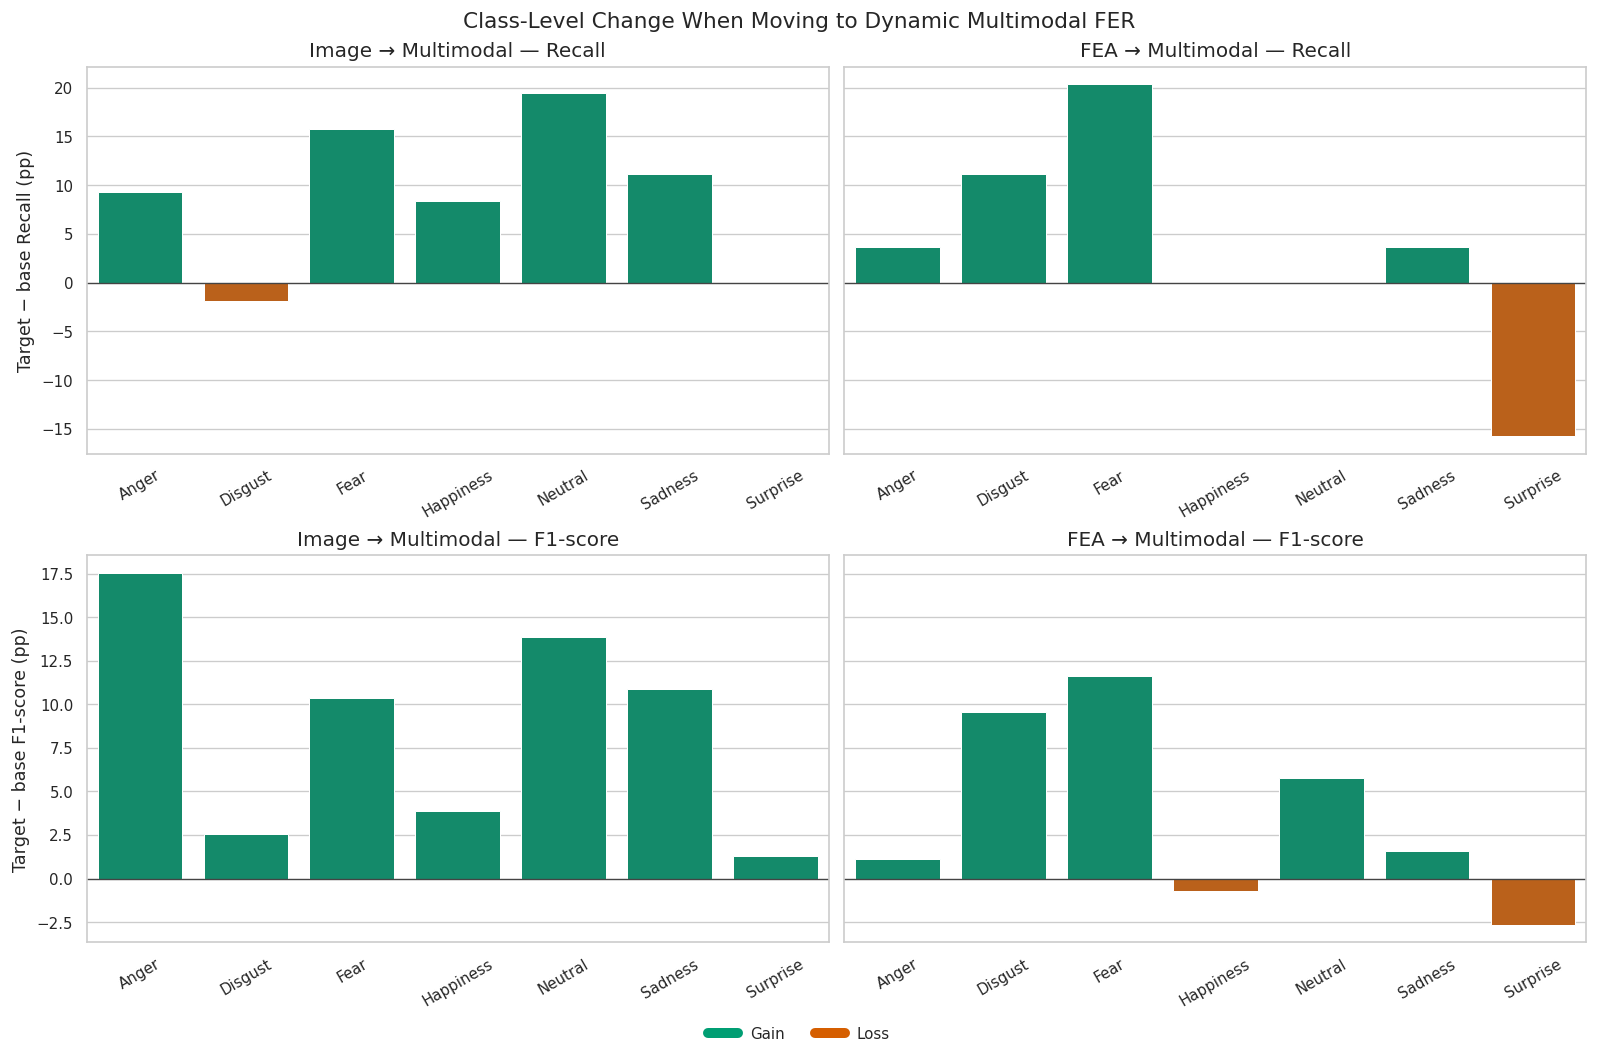

In [18]:
key_comparisons = ["Image → Multimodal", "FEA → Multimodal"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.2, 8.7),
    sharey="row",
    layout="constrained",
)

for row, (metric, label) in enumerate([
    ("delta_recall_pp", "Recall"),
    ("delta_f1_pp", "F1-score"),
]):
    for col, comparison in enumerate(key_comparisons):
        ax = axes[row, col]
        g = (
            pairwise_class[pairwise_class["comparison"] == comparison]
            .set_index("class")
            .reindex(CLASSES)
            .reset_index()
        )
        g["direction"] = np.where(g[metric] >= 0, "Gain", "Loss")

        sns.barplot(
            data=g,
            x="class",
            y=metric,
            hue="direction",
            hue_order=["Gain", "Loss"],
            palette={"Gain": POSITIVE_COLOR, "Loss": NEGATIVE_COLOR},
            dodge=False,
            edgecolor="white",
            linewidth=0.6,
            ax=ax,
        )

        ax.axhline(0, color="#444444", linewidth=0.8)
        ax.set(
            xlabel="",
            ylabel=f"Target − base {label} (pp)" if col == 0 else "",
            title=f"{comparison} — {label}",
        )
        ax.tick_params(axis="x", rotation=30)

        if ax.get_legend() is not None:
            ax.get_legend().remove()

fig.suptitle(
    "Class-Level Change When Moving to Dynamic Multimodal FER",
    fontsize=13,
)

legend_handles = [
    plt.Line2D([0], [0], color=POSITIVE_COLOR, lw=6, label="Gain"),
    plt.Line2D([0], [0], color=NEGATIVE_COLOR, lw=6, label="Loss"),
]
fig.legend(
    handles=legend_handles,
    loc="outside lower center",
    ncol=2,
    frameon=False,
)

finish_figure(fig, "08_dynamic_multimodal_class_recall_deltas")


### 6.1.1 Class-level gained and lost correct samples

The Recall/F1 deltas above show the **net performance change** per class. The following plot retains the underlying sample turnover by showing, for each class:

- **Gained correct:** the unimodal model is wrong and Dynamic Multimodal is correct (`target_only_correct`).
- **Lost correct:** the unimodal model is correct and Dynamic Multimodal is wrong (`base_only_correct`), plotted below zero.

Both can be non-zero for the same class. Therefore, a near-zero Recall delta can still hide substantial prediction turnover.

For **FEA → Multimodal**, the counts are view-aligned: each reenactment-level FEA decision occurs once for the Central and once for the Side multimodal sample. These are descriptive view-row counts, not independent FEA observations.


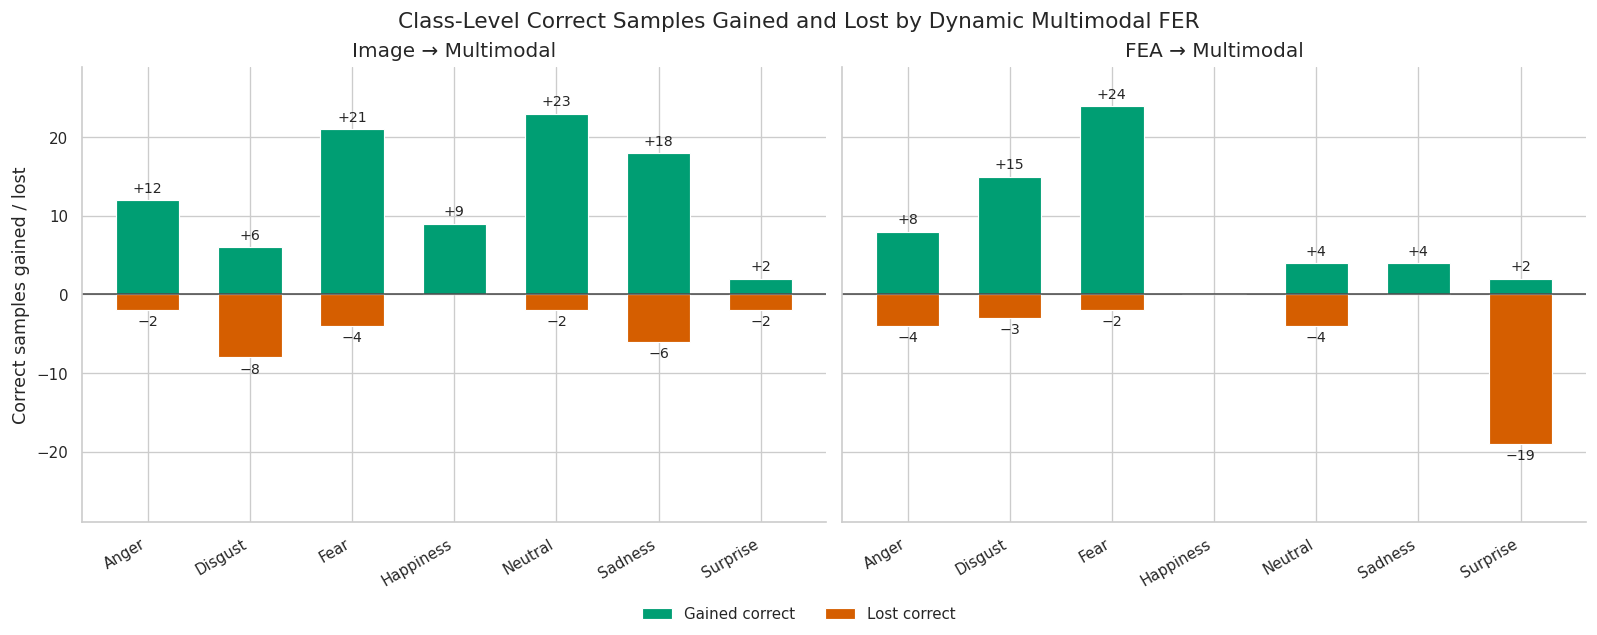

In [19]:
gain_loss_comparisons = ["Image → Multimodal", "FEA → Multimodal"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.2, 5.2),
    sharey=True,
    layout="constrained",
)

max_count = 0

for ax, comparison in zip(axes, gain_loss_comparisons):
    g = (
        pairwise_class[pairwise_class["comparison"] == comparison]
        .set_index("class")
        .reindex(CLASSES)
        .reset_index()
    )

    gained = g["target_only_correct"].to_numpy(dtype=int)
    lost = g["base_only_correct"].to_numpy(dtype=int)
    x = np.arange(len(CLASSES))

    max_count = max(max_count, int(gained.max()), int(lost.max()))

    gained_bars = ax.bar(
        x,
        gained,
        width=0.62,
        color=POSITIVE_COLOR,
        edgecolor="white",
        linewidth=0.7,
        label="Gained correct",
    )
    lost_bars = ax.bar(
        x,
        -lost,
        width=0.62,
        color=NEGATIVE_COLOR,
        edgecolor="white",
        linewidth=0.7,
        label="Lost correct",
    )

    ax.axhline(0, color="#444444", linewidth=0.9)
    ax.set_xticks(x, CLASSES, rotation=30, ha="right")
    ax.set_xlabel("")
    ax.set_title(comparison)

    for bar, value in zip(gained_bars, gained):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.6,
                f"+{value}",
                ha="center",
                va="bottom",
                fontsize=8.5,
            )

    for bar, value in zip(lost_bars, lost):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                -value - 0.6,
                f"−{value}",
                ha="center",
                va="top",
                fontsize=8.5,
            )

    sns.despine(ax=ax)

axes[0].set_ylabel("Correct samples gained / lost")

# Use a symmetric scale so gains and losses are visually comparable.
ylim = max_count + 5
for ax in axes:
    ax.set_ylim(-ylim, ylim)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="outside lower center",
    ncol=2,
    frameon=False,
)
fig.suptitle(
    "Class-Level Correct Samples Gained and Lost by Dynamic Multimodal FER",
    fontsize=13,
)

finish_figure(fig, "08b_dynamic_multimodal_gain_loss_counts")


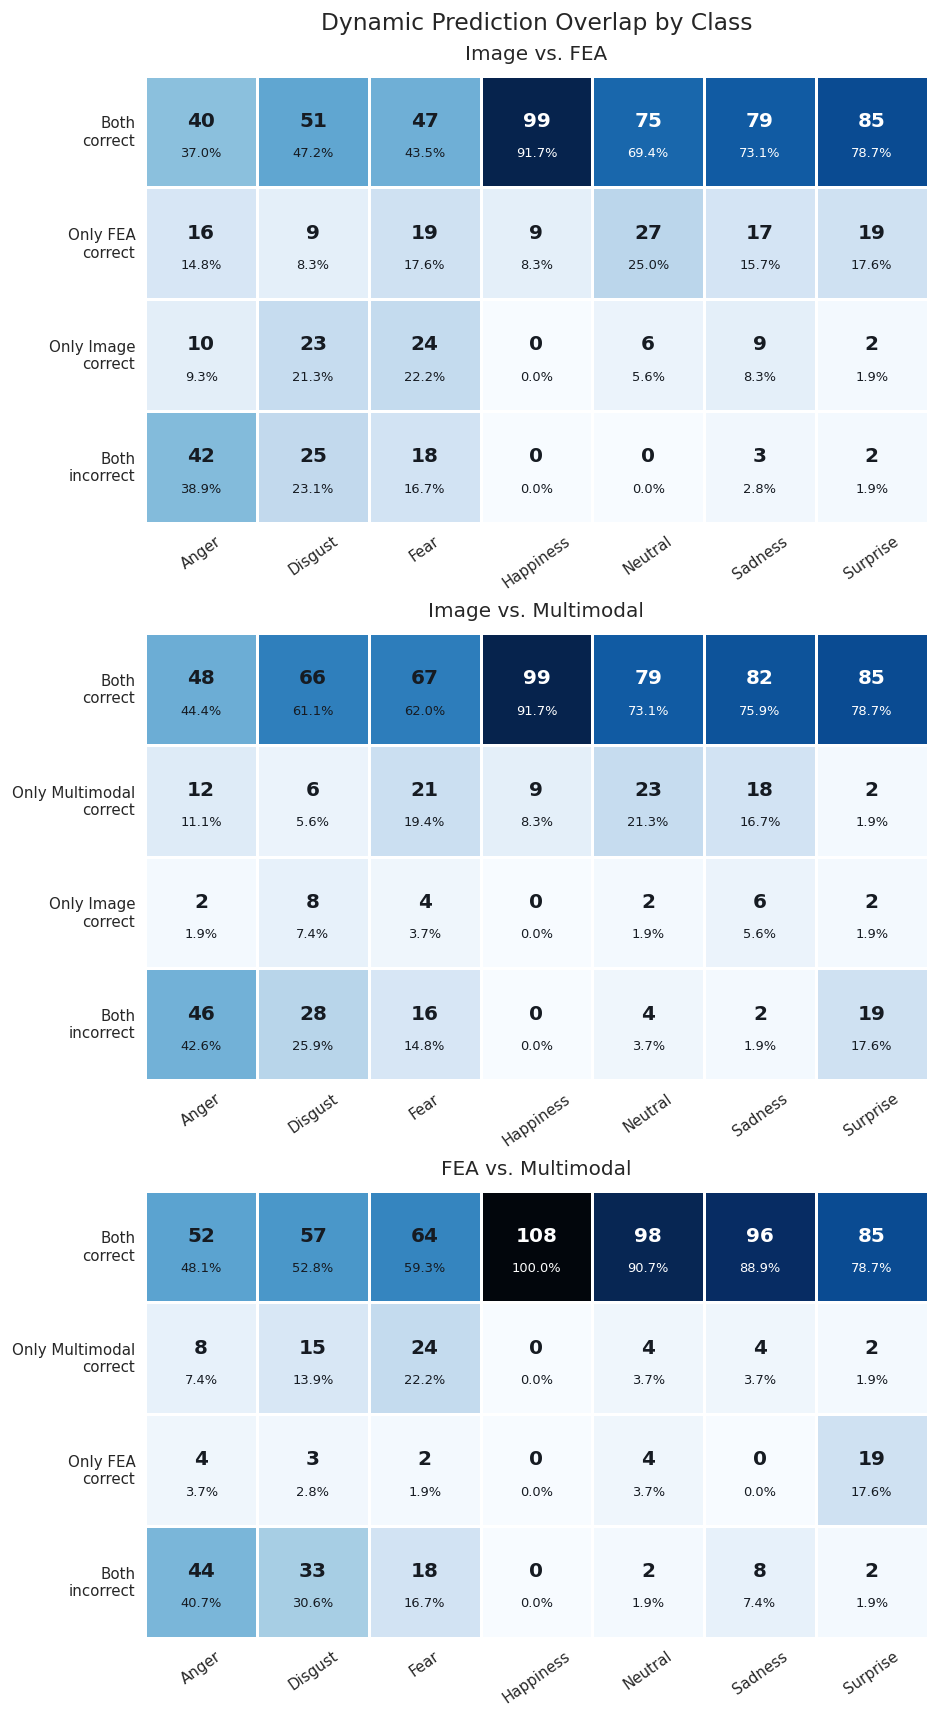

In [20]:
dynamic_pairwise_overlap_records = []
dynamic_pairwise_overlap_counts = {}

comparison_specs = [
    ("image", "fea"),
    ("image", "multimodal"),
    ("fea", "multimodal"),
]

for first, second in comparison_specs:
    d = dynamic.copy()
    d["first_correct"] = d[f"{first}_pred_id"] == d["true_label_id"]
    d["second_correct"] = d[f"{second}_pred_id"] == d["true_label_id"]

    counts = overlap_counts_by_class(
        d,
        first_correct_col="first_correct",
        second_correct_col="second_correct",
    )

    comparison_name = f"{DISPLAY[first]} vs. {DISPLAY[second]}"
    dynamic_pairwise_overlap_counts[(first, second)] = counts
    percentages = 100 * counts / counts.sum(axis=0, keepdims=True)

    overlap_names = [
        "both_correct",
        f"{second}_only_correct",
        f"{first}_only_correct",
        "both_incorrect",
    ]

    for row, outcome in enumerate(overlap_names):
        for col, class_name in enumerate(CLASSES):
            dynamic_pairwise_overlap_records.append({
                "comparison": comparison_name,
                "outcome": outcome,
                "class": class_name,
                "count": int(counts[row, col]),
                "class_percentage": float(percentages[row, col]),
            })

dynamic_pairwise_overlap = pd.DataFrame(dynamic_pairwise_overlap_records)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10.8, 14.2),
    layout="constrained",
)

row_labels_by_pair = {
    ("image", "fea"): [
        "Both\ncorrect",
        "Only FEA\ncorrect",
        "Only Image\ncorrect",
        "Both\nincorrect",
    ],
    ("image", "multimodal"): [
        "Both\ncorrect",
        "Only Multimodal\ncorrect",
        "Only Image\ncorrect",
        "Both\nincorrect",
    ],
    ("fea", "multimodal"): [
        "Both\ncorrect",
        "Only Multimodal\ncorrect",
        "Only FEA\ncorrect",
        "Both\nincorrect",
    ],
}

for ax, (first, second) in zip(axes, comparison_specs):
    draw_overlap_heatmap(
        ax,
        dynamic_pairwise_overlap_counts[(first, second)],
        row_labels=row_labels_by_pair[(first, second)],
        title=f"{DISPLAY[first]} vs. {DISPLAY[second]}",
    )

fig.suptitle(
    "Dynamic Prediction Overlap by Class",
    fontsize=14,
)

finish_figure(fig, "09_dynamic_modality_prediction_overlap")


### 6.2 Delta confusion matrices: Dynamic Multimodal − Dynamic Unimodal

These matrices compare Dynamic Multimodal against the two unimodal Dynamic baselines.

Two views are provided:

- **Count delta:**  
  - **Multimodal − Image** uses direct view-sample count subtraction because both matrices are defined on the same 756 aligned view rows.  
  - **Multimodal − FEA** uses a **view-aligned FEA matrix**, obtained by doubling every FEA confusion-matrix count. This is valid because each reenactment-level FEA prediction corresponds to exactly two multimodal samples (Central and Side). Thus, the doubled FEA matrix represents the confusion matrix that would arise if the same FEA prediction were repeated across both views.
- **Row-normalized delta:** computed in **percentage points (pp)**.

Interpretation:

- Positive **diagonal** values indicate higher Multimodal recall for that class.
- Positive **off-diagonal** values indicate that Multimodal assigns a larger number / fraction of that true class to the corresponding wrong class.

Important guardrail: doubling the FEA counts is only for a **descriptive count-level alignment** to the 756 multimodal view rows. It does **not** create 756 independent FEA observations and must not be used as a basis for inferential testing.


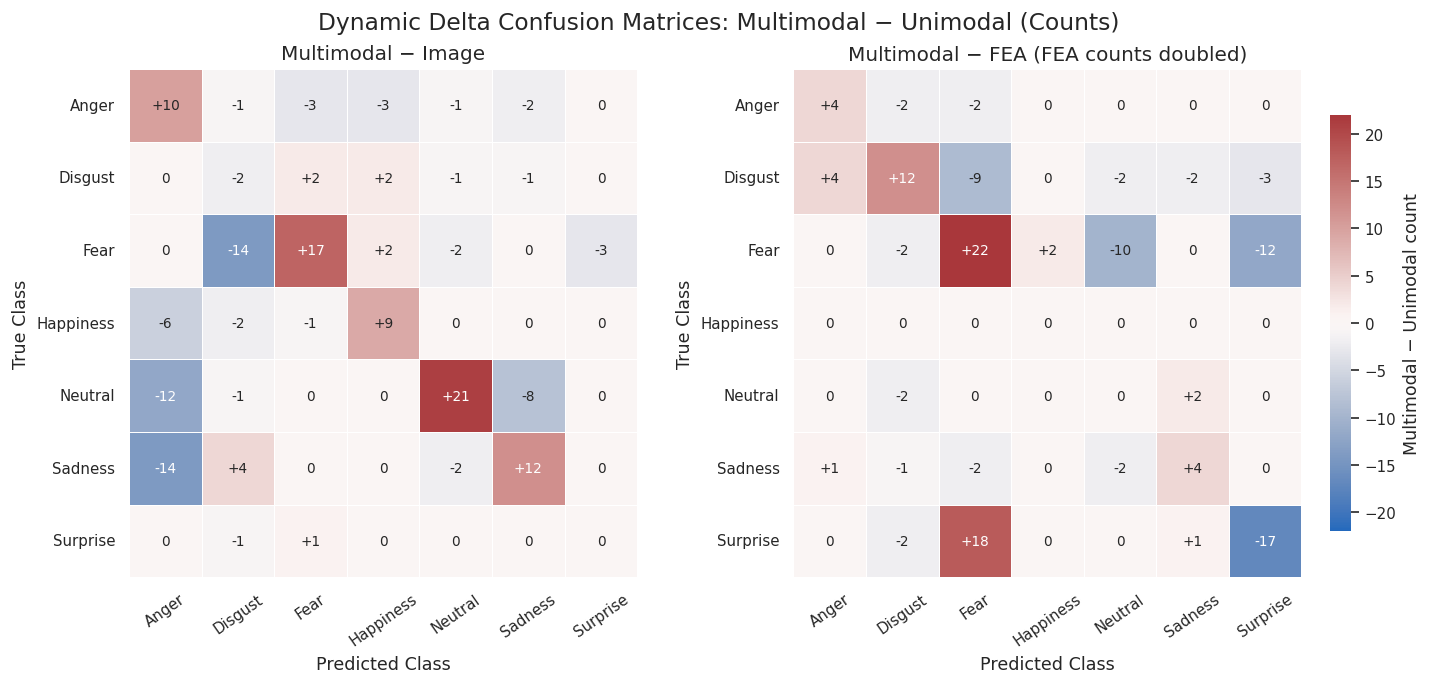

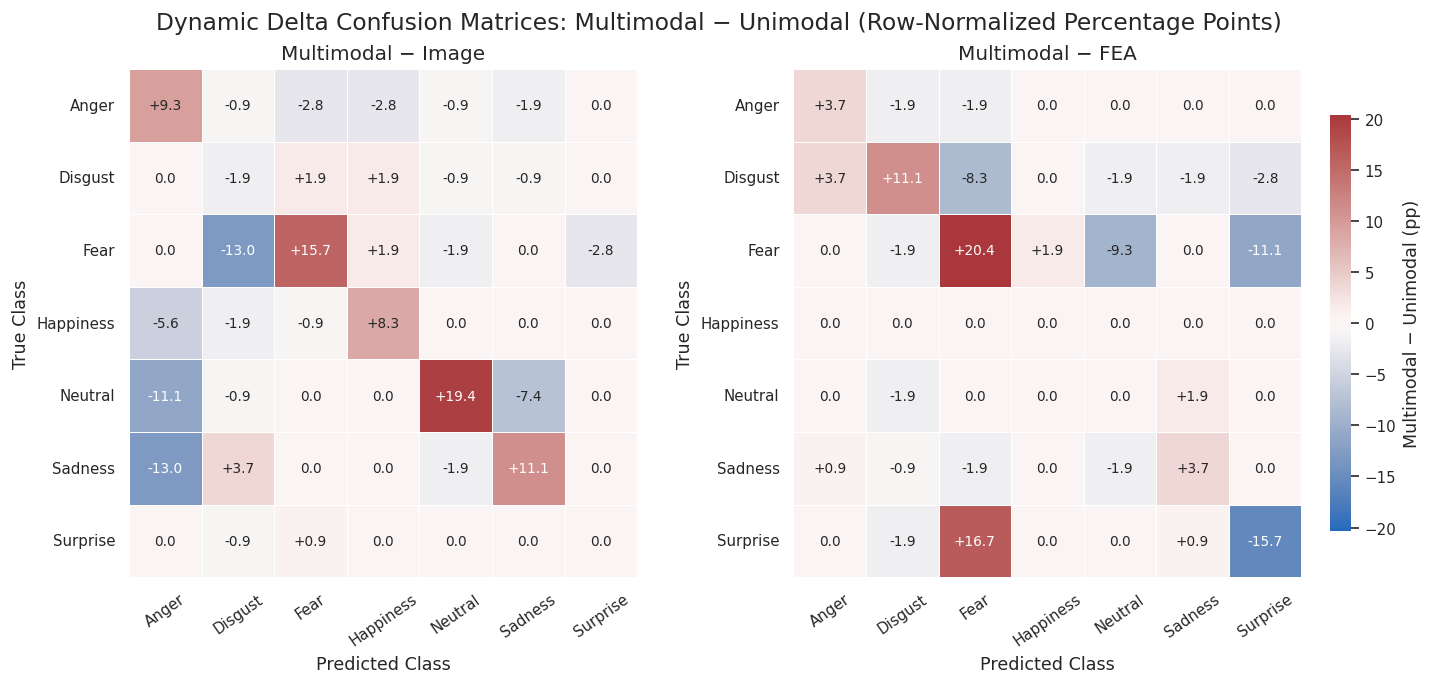

In [21]:
dynamic_multimodal_delta_records = []
dynamic_multimodal_delta_pp_records = []

dynamic_multimodal_delta_counts = {}
dynamic_multimodal_delta_pp = {}

multimodal_cm = confusion_cache[("Dynamic", "multimodal")].astype(float)
multimodal_norm = multimodal_cm / multimodal_cm.sum(axis=1, keepdims=True)

for unimodal in ["image", "fea"]:
    unimodal_cm_raw = confusion_cache[("Dynamic", unimodal)].astype(float)

    # For FEA, align the count matrix to the 756 multimodal view rows by
    # replicating each reenactment-level prediction across Central and Side.
    if unimodal == "fea":
        unimodal_cm_count_aligned = 2.0 * unimodal_cm_raw
        count_alignment = "FEA counts doubled to align with Central/Side view rows"
    else:
        unimodal_cm_count_aligned = unimodal_cm_raw.copy()
        count_alignment = "Direct view-level comparison"

    unimodal_norm = unimodal_cm_raw / unimodal_cm_raw.sum(axis=1, keepdims=True)

    delta_count = multimodal_cm - unimodal_cm_count_aligned
    delta_pp = 100 * (multimodal_norm - unimodal_norm)

    dynamic_multimodal_delta_counts[unimodal] = delta_count
    dynamic_multimodal_delta_pp[unimodal] = delta_pp

    comparison_name = f"Multimodal − {DISPLAY[unimodal]}"

    for i, true_class in enumerate(CLASSES):
        for j, predicted_class in enumerate(CLASSES):
            dynamic_multimodal_delta_records.append({
                "comparison": comparison_name,
                "count_alignment": count_alignment,
                "true_class": true_class,
                "predicted_class": predicted_class,
                "unimodal_count_aligned": int(unimodal_cm_count_aligned[i, j]),
                "multimodal_count": int(multimodal_cm[i, j]),
                "delta_count": int(delta_count[i, j]),
            })
            dynamic_multimodal_delta_pp_records.append({
                "comparison": comparison_name,
                "true_class": true_class,
                "predicted_class": predicted_class,
                "unimodal_row_pct": 100 * unimodal_norm[i, j],
                "multimodal_row_pct": 100 * multimodal_norm[i, j],
                "delta_row_pp": delta_pp[i, j],
            })

dynamic_multimodal_confusion_delta_counts = pd.DataFrame(dynamic_multimodal_delta_records)
dynamic_multimodal_confusion_delta_pp = pd.DataFrame(dynamic_multimodal_delta_pp_records)


# Count deltas.
max_abs_count = max(
    np.abs(matrix).max()
    for matrix in dynamic_multimodal_delta_counts.values()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.8, 5.6),
    layout="constrained",
)

for ax, unimodal in zip(axes, ["image", "fea"]):
    matrix = dynamic_multimodal_delta_counts[unimodal]
    annotations = np.vectorize(lambda x: "0" if x == 0 else f"{x:+.0f}")(matrix)

    sns.heatmap(
        matrix,
        annot=annotations,
        fmt="",
        cmap="vlag",
        center=0,
        vmin=-max_abs_count,
        vmax=max_abs_count,
        square=True,
        linewidths=0.6,
        linecolor="white",
        cbar=(unimodal == "fea"),
        cbar_kws={"label": "Multimodal − Unimodal count", "shrink": 0.82},
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        annot_kws={"fontsize": 8.2},
        ax=ax,
    )

    suffix = " (FEA counts doubled)" if unimodal == "fea" else ""
    ax.set_title(f"Multimodal − {DISPLAY[unimodal]}{suffix}")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Dynamic Delta Confusion Matrices: Multimodal − Unimodal (Counts)",
    fontsize=14,
)

finish_figure(fig, "12_dynamic_multimodal_unimodal_confusion_delta_counts")

# Row-normalized percentage-point deltas.
max_abs_pp = max(
    np.abs(matrix).max()
    for matrix in dynamic_multimodal_delta_pp.values()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.8, 5.6),
    layout="constrained",
)

for ax, unimodal in zip(axes, ["image", "fea"]):
    matrix = dynamic_multimodal_delta_pp[unimodal]
    annotations = np.vectorize(lambda x: "0.0" if np.isclose(x, 0) else f"{x:+.1f}")(matrix)

    sns.heatmap(
        matrix,
        annot=annotations,
        fmt="",
        cmap="vlag",
        center=0,
        vmin=-max_abs_pp,
        vmax=max_abs_pp,
        square=True,
        linewidths=0.6,
        linecolor="white",
        cbar=(unimodal == "fea"),
        cbar_kws={"label": "Multimodal − Unimodal (pp)", "shrink": 0.82},
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        annot_kws={"fontsize": 8.2},
        ax=ax,
    )

    ax.set_title(f"Multimodal − {DISPLAY[unimodal]}")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Dynamic Delta Confusion Matrices: Multimodal − Unimodal (Row-Normalized Percentage Points)",
    fontsize=14,
)

finish_figure(fig, "13_dynamic_multimodal_unimodal_confusion_delta_normalized")


## 7. Fusion within joint unimodal correctness groups

For **each setting separately**, partition the aligned view rows using the correctness of Image and FEA, then evaluate the Multimodal prediction within each of the four groups. This is a three-model analysis: the earlier pairwise overlaps do not determine these conditional outcomes.

Report the group size, correct and incorrect fusion predictions, and the fraction correct **within the group**. The groups are mutually exclusive and exhaustive. For the both-correct group, fusion errors are losses; for both-wrong, fusion successes are recoveries beyond selecting an existing unimodal prediction. For either one-correct group, the rate describes successful recovery of the available correct class, not proof of an internal modality-selection mechanism.

All counts use 756 aligned view rows, including duplicated FEA decisions. Class and view breakdowns are descriptive; empty groups have undefined rates. Static and Dynamic group memberships can differ, so differences between their conditional rates are not paired causal effects. No new significance tests are performed. The prediction-selection oracle is a reference based on the union of unimodal successes, not a strict ceiling for a learned fusion model.


In [22]:
FUSION_GROUPS = ["both_correct", "image_only_correct", "fea_only_correct", "both_wrong"]
FUSION_GROUP_LABELS = {
    "both_correct": "Both correct",
    "image_only_correct": "Only Image correct",
    "fea_only_correct": "Only FEA correct",
    "both_wrong": "Both wrong",
}

def summarize_fusion_groups(df, setting, **stratum):
    records = []
    for group in FUSION_GROUPS:
        g = df.loc[df["unimodal_group"] == group]
        size = len(g)
        correct = int(g["fusion_correct"].sum())
        records.append({
            "setting": setting,
            **stratum,
            "unimodal_group": group,
            "n_view_rows": size,
            "fusion_correct": correct,
            "fusion_wrong": size - correct,
            "fusion_accuracy": correct / size if size else np.nan,
        })
    return records

fusion_group_records = []
fusion_group_class_records = []
fusion_group_view_records = []
fusion_oracle_records = []

for setting, frame in [("Static", static), ("Dynamic", dynamic)]:
    d = frame.copy()
    image_correct = d["image_pred_id"] == d["true_label_id"]
    fea_correct = d["fea_pred_id"] == d["true_label_id"]
    d["fusion_correct"] = d["multimodal_pred_id"] == d["true_label_id"]
    d["unimodal_group"] = np.select(
        [image_correct & fea_correct, image_correct & ~fea_correct,
         ~image_correct & fea_correct, ~image_correct & ~fea_correct],
        FUSION_GROUPS,
        default="unclassified",
    )
    assert not d["unimodal_group"].eq("unclassified").any()
    summary = summarize_fusion_groups(d, setting)
    assert sum(r["n_view_rows"] for r in summary) == len(d)
    assert sum(r["fusion_correct"] for r in summary) == int(d["fusion_correct"].sum())
    fusion_group_records.extend(summary)

    for class_id, class_name in enumerate(CLASSES):
        fusion_group_class_records.extend(summarize_fusion_groups(
            d.loc[d["true_label_id"] == class_id], setting, **{"class": class_name}
        ))
    for view in ["Central", "Side"]:
        fusion_group_view_records.extend(summarize_fusion_groups(
            d.loc[d["perspective"] == view], setting, perspective=view
        ))

    oracle_correct = image_correct | fea_correct
    oracle_n = int(oracle_correct.sum())
    missed_available = int((oracle_correct & ~d["fusion_correct"]).sum())
    recovered_both_wrong = int((~oracle_correct & d["fusion_correct"]).sum())
    fusion_n = int(d["fusion_correct"].sum())
    assert fusion_n == oracle_n - missed_available + recovered_both_wrong
    fusion_oracle_records.append({
        "setting": setting,
        "n_view_rows": len(d),
        "oracle_correct": oracle_n,
        "missed_available_correct": missed_available,
        "recovered_both_wrong": recovered_both_wrong,
        "fusion_correct": fusion_n,
        "oracle_accuracy": oracle_n / len(d),
        "fusion_accuracy": fusion_n / len(d),
        "oracle_minus_fusion_pp": 100 * (oracle_n - fusion_n) / len(d),
    })

fusion_groups = pd.DataFrame(fusion_group_records)
fusion_groups_by_class = pd.DataFrame(fusion_group_class_records)
fusion_groups_by_view = pd.DataFrame(fusion_group_view_records)
fusion_oracle_summary = pd.DataFrame(fusion_oracle_records)

# Both descriptive stratifications must reconstruct the overall group counts.
count_columns = ["n_view_rows", "fusion_correct", "fusion_wrong"]
overall_counts = fusion_groups.set_index(["setting", "unimodal_group"])[count_columns].sort_index()
for breakdown in [fusion_groups_by_class, fusion_groups_by_view]:
    reconstructed = breakdown.groupby(["setting", "unimodal_group"])[count_columns].sum().sort_index()
    pd.testing.assert_frame_equal(reconstructed, overall_counts)

for table, name in [
    (fusion_groups, "fusion_correctness_groups.csv"),
    (fusion_groups_by_class, "fusion_correctness_groups_by_class.csv"),
    (fusion_groups_by_view, "fusion_correctness_groups_by_view.csv"),
]:
    table.to_csv(TABLE_DIR / name, index=False)

fusion_groups


,setting,unimodal_group,n_view_rows,fusion_correct,fusion_wrong,fusion_accuracy
0,Static,both_correct,414,411,3,0.992754
1,Static,image_only_correct,114,95,19,0.833333
2,Static,fea_only_correct,128,84,44,0.656250
3,Static,both_wrong,100,18,82,0.180000
4,Dynamic,both_correct,476,474,2,0.995798
5,Dynamic,image_only_correct,74,52,22,0.702703
6,Dynamic,fea_only_correct,116,86,30,0.741379
7,Dynamic,both_wrong,90,5,85,0.055556


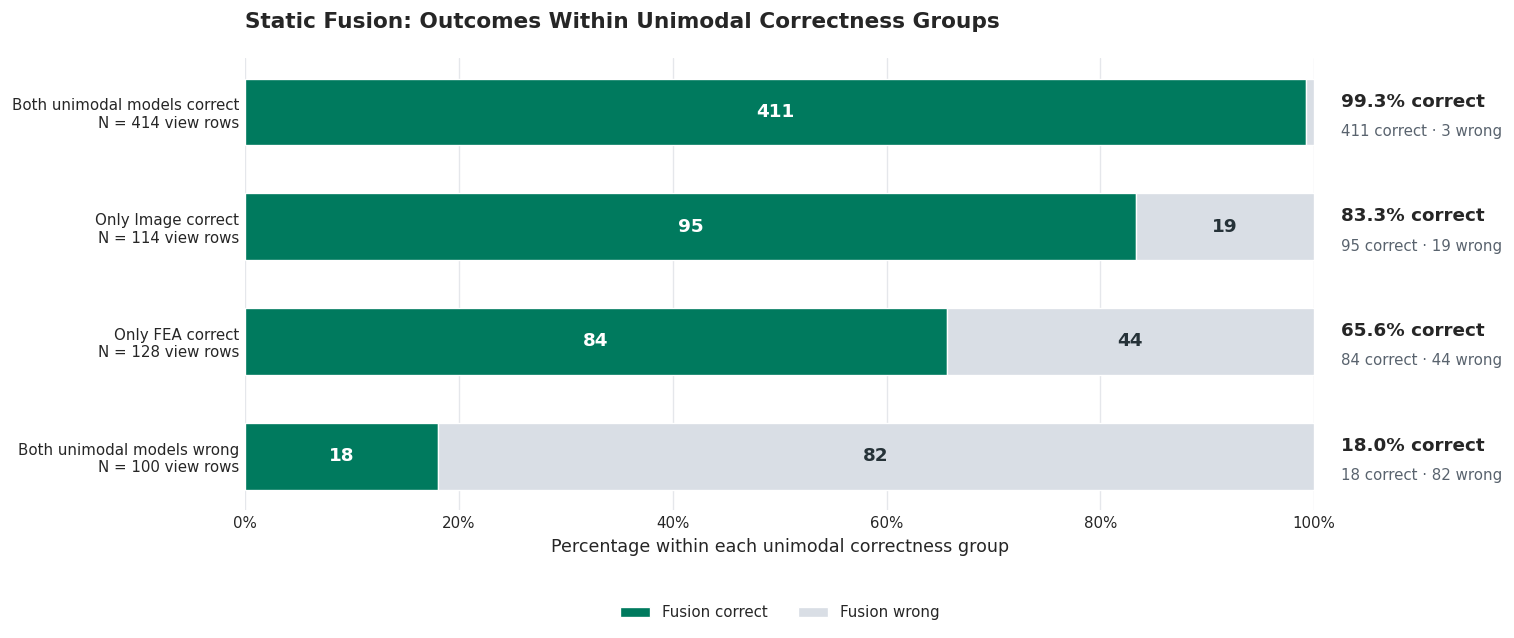

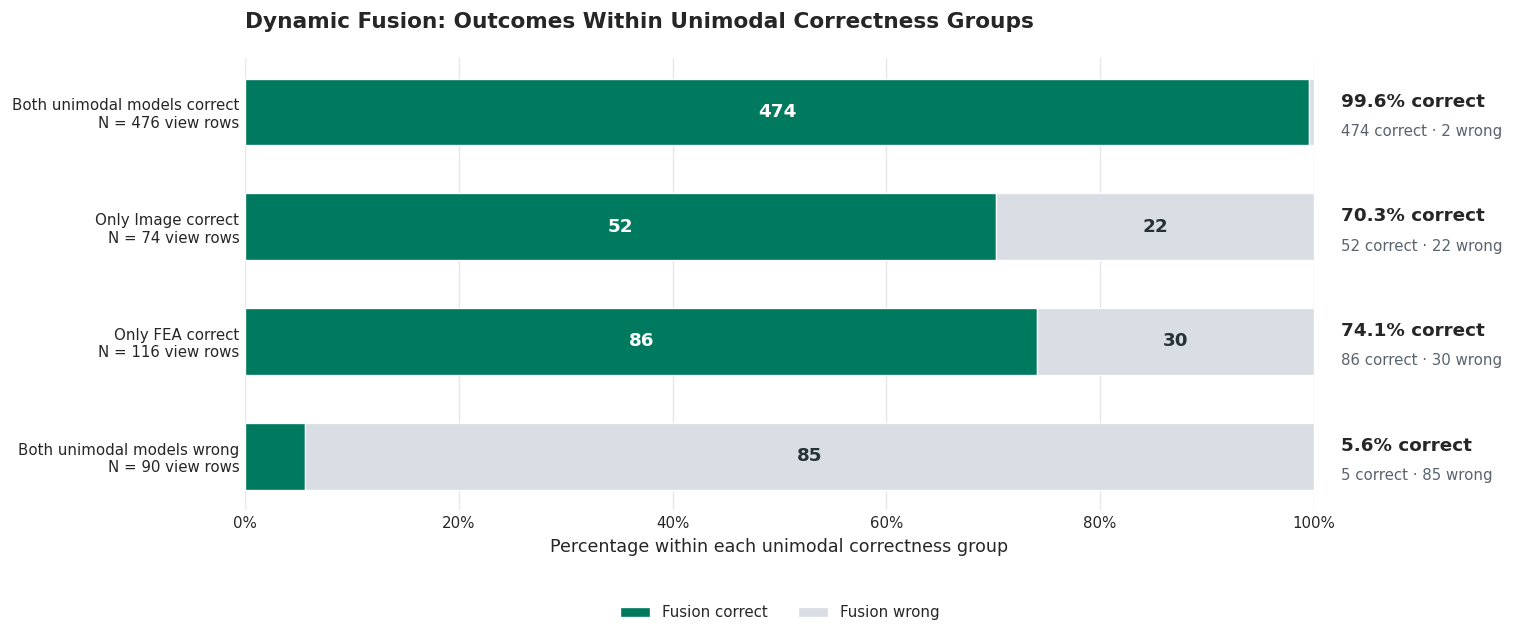

In [23]:
# Fusion accuracy within each joint unimodal correctness group.
# Uses fusion_groups, FUSION_GROUPS, and finish_figure from the notebook.

group_labels = {
    "both_correct": "Both unimodal models correct",
    "image_only_correct": "Only Image correct",
    "fea_only_correct": "Only FEA correct",
    "both_wrong": "Both unimodal models wrong",
}

for setting, figure_name in [
    ("Static", "14_static_fusion_correctness_groups"),
    ("Dynamic", "15_dynamic_fusion_correctness_groups"),
]:
    table = (
        fusion_groups.loc[fusion_groups["setting"] == setting]
        .set_index("unimodal_group")
        .loc[FUSION_GROUPS]
    )

    sizes = table["n_view_rows"].to_numpy(dtype=int)
    correct = table["fusion_correct"].to_numpy(dtype=int)
    wrong = table["fusion_wrong"].to_numpy(dtype=int)

    correct_pct = np.divide(
        100.0 * correct,
        sizes,
        out=np.zeros(len(table), dtype=float),
        where=sizes > 0,
    )
    wrong_pct = np.where(sizes > 0, 100.0 - correct_pct, 0.0)
    positions = np.arange(len(table))

    fig, ax = plt.subplots(figsize=(12.5, 5.2), layout="constrained")

    ax.barh(
        positions,
        correct_pct,
        height=0.58,
        color="#007A5E",
        label="Fusion correct",
        zorder=3,
    )
    ax.barh(
        positions,
        wrong_pct,
        left=correct_pct,
        height=0.58,
        color="#D9DEE5",
        label="Fusion wrong",
        zorder=3,
    )

    # Segment labels show counts when there is enough space.
    # The annotation at the right always reports both exact counts.
    for y, n, n_correct, n_wrong, pct in zip(
        positions, sizes, correct, wrong, correct_pct
    ):
        if n > 0 and pct >= 12:
            ax.text(
                pct / 2, y, str(n_correct),
                ha="center", va="center",
                color="white", fontsize=11, fontweight="bold",
            )
        if n > 0 and 100 - pct >= 12:
            ax.text(
                pct + (100 - pct) / 2, y, str(n_wrong),
                ha="center", va="center",
                color="#263238", fontsize=11, fontweight="bold",
            )

        rate_label = f"{pct:.1f}% correct" if n else "Empty group"
        ax.text(
            1.025, y - 0.09, rate_label,
            transform=ax.get_yaxis_transform(),
            ha="left", va="center",
            fontsize=11, fontweight="bold", clip_on=False,
        )
        ax.text(
            1.025, y + 0.17,
            f"{n_correct} correct · {n_wrong} wrong",
            transform=ax.get_yaxis_transform(),
            ha="left", va="center",
            fontsize=9, color="#59636E", clip_on=False,
        )

    ax.set_yticks(
        positions,
        [
            f"{group_labels[group]}\nN = {n} view rows"
            for group, n in zip(table.index, sizes)
        ],
    )
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.set_xlabel("Percentage within each unimodal correctness group")
    ax.set_ylabel("")
    ax.set_title(
        f"{setting} Fusion: Outcomes Within Unimodal Correctness Groups",
        loc="left", fontsize=13, fontweight="bold", pad=18,
    )

    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="both", length=0)
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
    )

    finish_figure(fig, figure_name)

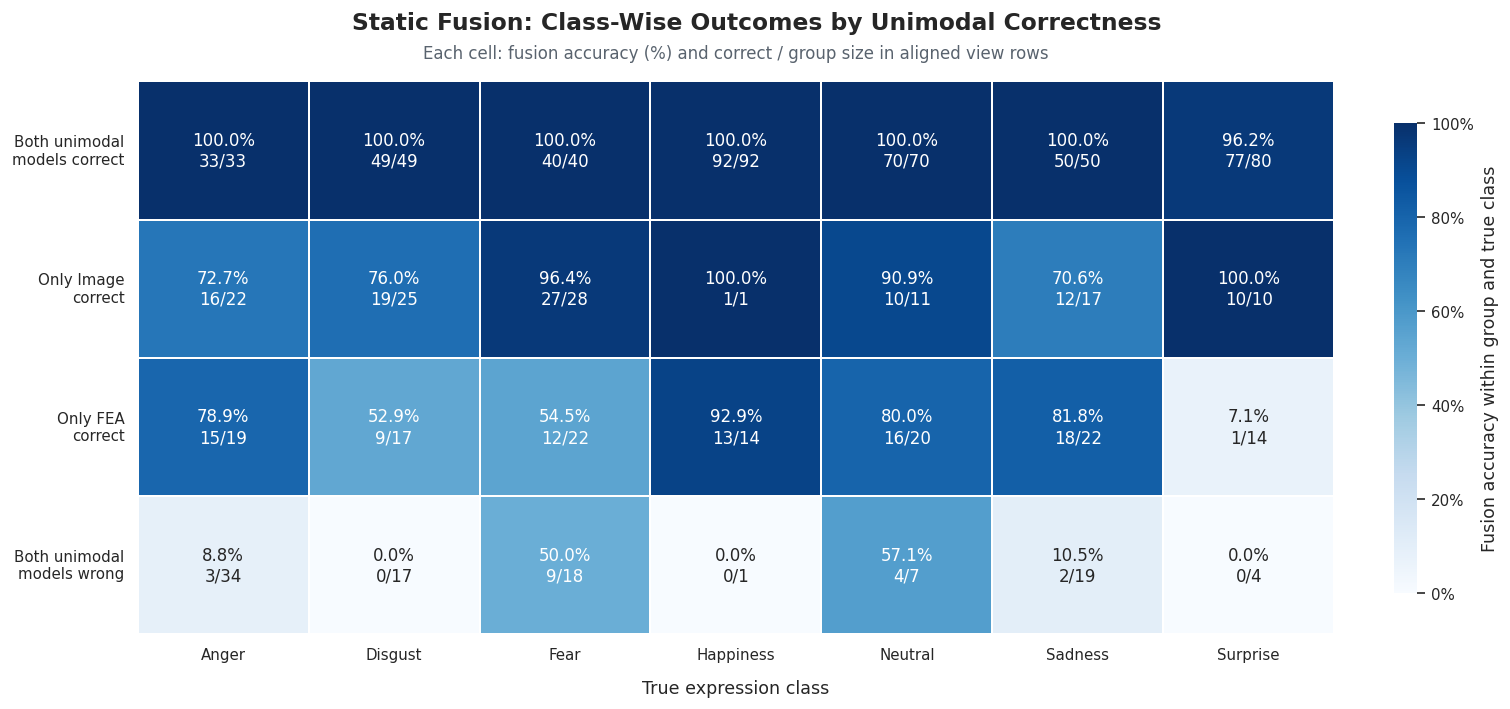

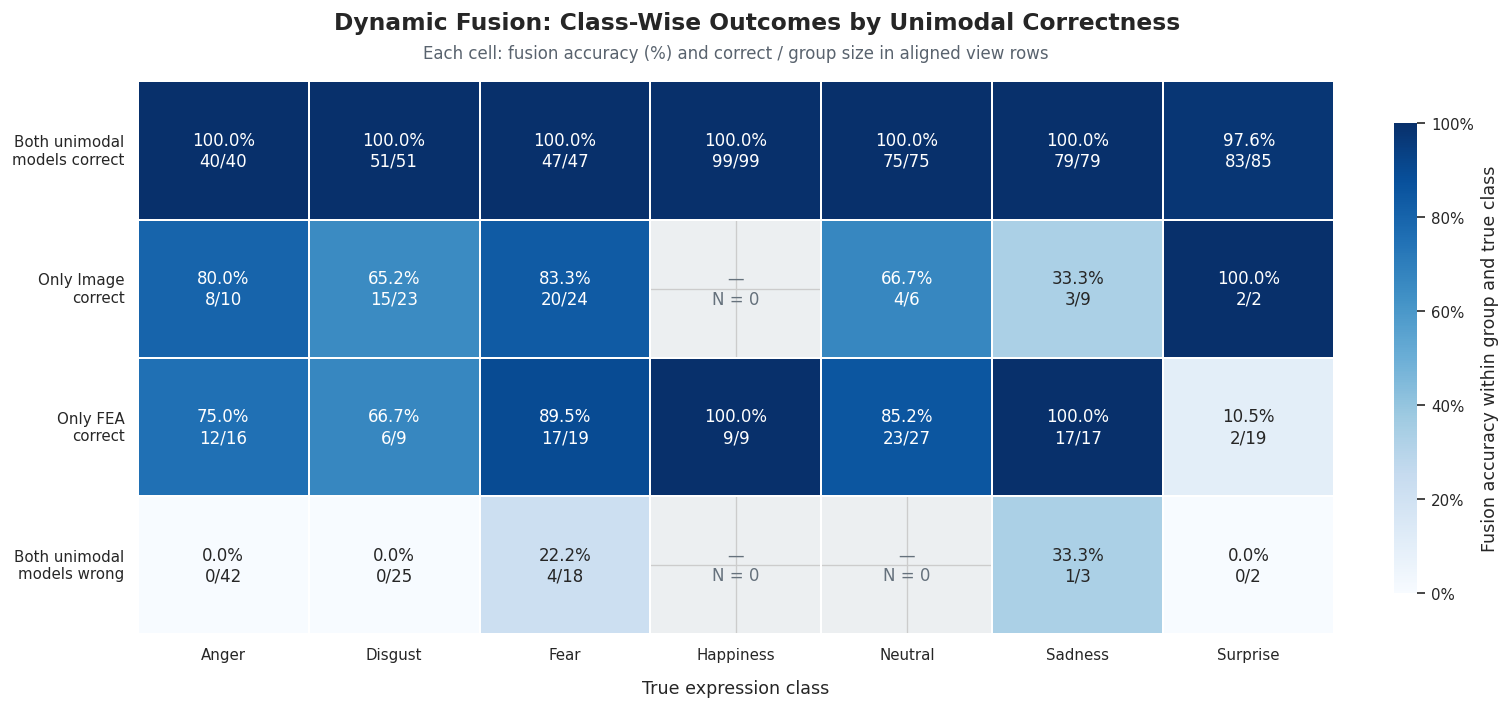

In [24]:
# Class-wise fusion performance within joint unimodal correctness groups.
# Identical color scales support comparison between Static and Dynamic.

row_labels = [
    "Both unimodal\nmodels correct",
    "Only Image\ncorrect",
    "Only FEA\ncorrect",
    "Both unimodal\nmodels wrong",
]

for setting, figure_name in [
    ("Static", "16_static_fusion_correctness_groups_by_class"),
    ("Dynamic", "17_dynamic_fusion_correctness_groups_by_class"),
]:
    subset = fusion_groups_by_class.loc[
        fusion_groups_by_class["setting"] == setting
    ]

    sizes = (
        subset.pivot(
            index="unimodal_group",
            columns="class",
            values="n_view_rows",
        )
        .reindex(index=FUSION_GROUPS, columns=CLASSES)
        .fillna(0)
        .astype(int)
    )

    correct = (
        subset.pivot(
            index="unimodal_group",
            columns="class",
            values="fusion_correct",
        )
        .reindex(index=FUSION_GROUPS, columns=CLASSES)
        .fillna(0)
        .astype(int)
    )

    # Empty groups have undefined accuracy, not 0% accuracy.
    percentages = 100 * correct.div(sizes.replace(0, np.nan))
    empty = sizes.eq(0)

    annotations = np.full(sizes.shape, "", dtype=object)
    for row, col in np.ndindex(sizes.shape):
        n = sizes.iat[row, col]
        if n:
            annotations[row, col] = (
                f"{percentages.iat[row, col]:.1f}%\n"
                f"{correct.iat[row, col]}/{n}"
            )

    fig, ax = plt.subplots(
        figsize=(12.5, 5.8),
        layout="constrained",
    )

    # Masked cells remain gray and receive an explicit empty-group label.
    ax.set_facecolor("#ECEFF1")

    sns.heatmap(
        percentages,
        mask=empty,
        annot=annotations,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=100,
        linewidths=1,
        linecolor="white",
        xticklabels=CLASSES,
        yticklabels=row_labels,
        annot_kws={"fontsize": 10},
        cbar_kws={
            "label": "Fusion accuracy within group and true class",
            "format": PercentFormatter(xmax=100),
            "shrink": 0.85,
        },
        ax=ax,
    )

    for row, col in np.argwhere(empty.to_numpy()):
        ax.text(
            col + 0.5,
            row + 0.5,
            "—\nN = 0",
            ha="center",
            va="center",
            fontsize=10,
            color="#65717C",
        )

    ax.set_xlabel("True expression class", labelpad=10)
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0, length=0, pad=8)
    ax.tick_params(axis="y", rotation=0, length=0, pad=8)

    fig.suptitle(
        f"{setting} Fusion: Class-Wise Outcomes by Unimodal Correctness",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_title(
        "Each cell: fusion accuracy (%) and correct / group size "
        "in aligned view rows",
        fontsize=10,
        color="#59636E",
        pad=14,
    )

    finish_figure(fig, figure_name)

## 8. Compact Error Analysis Report


In [25]:
def md_table(df):
    cols = [str(c) for c in df.columns]
    lines = [
        "| " + " | ".join(cols) + " |",
        "| " + " | ".join(["---"] * len(cols)) + " |",
    ]
    for row in df.itertuples(index=False, name=None):
        lines.append("| " + " | ".join(str(v) for v in row) + " |")
    return "\n".join(lines)


overall_report = static_dynamic_overall.copy()
overall_report["Static Accuracy"] = overall_report["static_accuracy"].map(lambda x: f"{100*x:.2f}%")
overall_report["Dynamic Accuracy"] = overall_report["dynamic_accuracy"].map(lambda x: f"{100*x:.2f}%")
overall_report["Δ Accuracy"] = overall_report["delta_accuracy_pp"].map(lambda x: f"{x:+.2f} pp")
overall_report["Static Macro-F1"] = overall_report["static_macro_f1"].map(lambda x: f"{100*x:.2f}%")
overall_report["Dynamic Macro-F1"] = overall_report["dynamic_macro_f1"].map(lambda x: f"{100*x:.2f}%")
overall_report["Δ Macro-F1"] = overall_report["delta_macro_f1_pp"].map(lambda x: f"{x:+.2f} pp")
overall_report = overall_report[
    [
        "modality", "analysis_unit",
        "Static Accuracy", "Dynamic Accuracy", "Δ Accuracy",
        "Static Macro-F1", "Dynamic Macro-F1", "Δ Macro-F1",
    ]
].rename(columns={
    "modality": "Modality",
    "analysis_unit": "Unit",
})

class_delta_report = static_dynamic_class_comparison[
    ["modality", "class", "delta_recall_pp", "delta_f1_pp"]
].copy()
class_delta_report["Recall Δ"] = class_delta_report["delta_recall_pp"].map(lambda x: f"{x:+.2f} pp")
class_delta_report["F1 Δ"] = class_delta_report["delta_f1_pp"].map(lambda x: f"{x:+.2f} pp")
class_delta_report = class_delta_report[
    ["modality", "class", "Recall Δ", "F1 Δ"]
].rename(columns={"modality": "Modality", "class": "Class"})

pair_report = pairwise_overall.copy()
pair_report["Base"] = pair_report["base_accuracy"].map(lambda x: f"{100*x:.2f}%")
pair_report["Target"] = pair_report["target_accuracy"].map(lambda x: f"{100*x:.2f}%")
pair_report["Δ"] = pair_report["delta_accuracy_pp"].map(lambda x: f"{x:+.2f} pp")
pair_report["Error rescue"] = pair_report["base_error_rescue_rate"].map(lambda x: f"{100*x:.2f}%")
pair_report["Correct retention"] = pair_report["base_correct_retention_rate"].map(lambda x: f"{100*x:.2f}%")
pair_report = pair_report[
    [
        "comparison", "Base", "Target", "Δ",
        "base_only_correct", "target_only_correct",
        "Error rescue", "Correct retention",
    ]
].rename(columns={
    "comparison": "Comparison",
    "base_only_correct": "Base-only correct",
    "target_only_correct": "Target-only correct",
})

key_delta = pairwise_class[
    pairwise_class["comparison"].isin(key_comparisons)
][
    ["comparison", "class", "delta_recall_pp", "delta_f1_pp"]
].copy()
key_delta["Recall Δ"] = key_delta["delta_recall_pp"].map(lambda x: f"{x:+.2f} pp")
key_delta["F1 Δ"] = key_delta["delta_f1_pp"].map(lambda x: f"{x:+.2f} pp")
key_delta = key_delta[
    ["comparison", "class", "Recall Δ", "F1 Δ"]
].rename(columns={"comparison": "Comparison", "class": "Class"})

top_dynamic_report = []
for modality in [DISPLAY[m] for m in MODALITIES]:
    g = (
        top_dynamic_errors[top_dynamic_errors["modality"] == modality]
        .sort_values("count", ascending=False)
        .head(5)
    )
    for row in g.itertuples(index=False):
        top_dynamic_report.append({
            "Modality": modality,
            "Error": f"{row.true_class} → {row.predicted_class}",
            "Count": row.count,
        })
top_dynamic_report = pd.DataFrame(top_dynamic_report)


def strongest_delta(df, modality, metric):
    g = df[df["modality"] == modality].set_index("class")[metric]
    return g.idxmax(), float(g.max()), g.idxmin(), float(g.min())


img_sd = static_dynamic_overall.set_index("modality").loc["Image"]
fea_sd = static_dynamic_overall.set_index("modality").loc["FEA"]
mm_sd = static_dynamic_overall.set_index("modality").loc["Multimodal"]

img_mm = pairwise_overall.set_index("comparison").loc["Image → Multimodal"]
fea_mm = pairwise_overall.set_index("comparison").loc["FEA → Multimodal"]
img_fea = pairwise_overall.set_index("comparison").loc["Image → FEA"]

img_rec_best, img_rec_best_v, img_rec_worst, img_rec_worst_v = strongest_delta(
    static_dynamic_class_comparison, "Image", "delta_recall_pp"
)
fea_rec_best, fea_rec_best_v, fea_rec_worst, fea_rec_worst_v = strongest_delta(
    static_dynamic_class_comparison, "FEA", "delta_recall_pp"
)
mm_rec_best, mm_rec_best_v, mm_rec_worst, mm_rec_worst_v = strongest_delta(
    static_dynamic_class_comparison, "Multimodal", "delta_recall_pp"
)

img_fea_class = pairwise_class[pairwise_class["comparison"] == "Image → FEA"].copy()
fea_adv = img_fea_class.loc[img_fea_class["delta_recall_pp"].idxmax()]
img_adv = img_fea_class.loc[img_fea_class["delta_recall_pp"].idxmin()]


fusion_group_report = fusion_groups.copy()
fusion_group_report["Group"] = fusion_group_report["unimodal_group"].map(FUSION_GROUP_LABELS)
fusion_group_report["Fusion accuracy within group"] = fusion_group_report["fusion_accuracy"].map(
    lambda v: "NA (empty group)" if pd.isna(v) else f"{100*v:.2f}%"
)
fusion_group_report = fusion_group_report[
    ["setting", "Group", "n_view_rows", "fusion_correct", "fusion_wrong", "Fusion accuracy within group"]
].rename(columns={"setting": "Setting", "n_view_rows": "Group N", "fusion_correct": "Fusion correct", "fusion_wrong": "Fusion wrong"})

oracle_report = fusion_oracle_summary[
    ["setting", "oracle_correct", "missed_available_correct", "recovered_both_wrong", "fusion_correct"]
].rename(columns={
    "setting": "Setting", "oracle_correct": "At least one unimodal correct",
    "missed_available_correct": "Available correct class lost",
    "recovered_both_wrong": "Both-wrong cases recovered", "fusion_correct": "Fusion correct",
})

fusion_group_index = fusion_groups.set_index(["setting", "unimodal_group"])
static_both = fusion_group_index.loc[("Static", "both_correct")]
dynamic_both = fusion_group_index.loc[("Dynamic", "both_correct")]
static_neither = fusion_group_index.loc[("Static", "both_wrong")]
dynamic_neither = fusion_group_index.loc[("Dynamic", "both_wrong")]

report = f"""# Static–Dynamic and Multimodal Error Analysis

## Scope

This report summarizes descriptive error patterns from `static_test_predictions.csv` and `dynamic_test_predictions.csv`.

- Image and Multimodal analyses use **756 view samples**.
- FEA-only analyses use **378 reenactments**.
- In cross-modality comparisons involving FEA and a view-specific model, the FEA prediction is repeated for the Central and Side rows of the same reenactment. Those aligned rows are useful for descriptive sample pairing, but are not independent FEA observations.
- **Recall is the primary class-wise error-analysis metric** because it maps directly to row-normalized confusion matrices and true-class-based overlap heatmaps. **F1-score is reported alongside Recall** to reveal whether recall changes are accompanied by changes in false-positive behavior.
- Inferential significance is reported separately in the dedicated significance-test reports.

## Confusion-matrix overview

All six settings use the same class order and a common row-normalized color scale. Counts preserve the different analysis units: 108 view rows per class for Image/Multimodal and 54 unique reenactments per class for FEA.

![All six confusion matrices: counts and percentages](figures/01_confusion_matrices_counts.png)

![All six confusion matrices: row-normalized percentages](figures/02_confusion_matrices_normalized.png)

## 1. Overall Static → Dynamic changes

{md_table(overall_report)}

The overall pattern is consistent for Accuracy and Macro-F1. The evaluated Dynamic models show the largest Static–Dynamic gain for **FEA** (**{fea_sd.delta_accuracy_pp:+.2f} pp Accuracy; {fea_sd.delta_macro_f1_pp:+.2f} pp Macro-F1**), followed by **Image** (**{img_sd.delta_accuracy_pp:+.2f}; {img_sd.delta_macro_f1_pp:+.2f} pp**) and **Multimodal** (**{mm_sd.delta_accuracy_pp:+.2f}; {mm_sd.delta_macro_f1_pp:+.2f} pp**).

At sample level, Dynamic FEA corrects **{int(fea_sd.dynamic_only_correct)}** reenactments that Static FEA misses while losing **{int(fea_sd.static_only_correct)}** previously correct reenactments. Dynamic Image corrects **{int(img_sd.dynamic_only_correct)}** view samples and loses **{int(img_sd.static_only_correct)}**; Dynamic Multimodal corrects **{int(mm_sd.dynamic_only_correct)}** and loses **{int(mm_sd.static_only_correct)}**.

![Static vs Dynamic overall performance](figures/03_static_dynamic_overall_accuracy.png)

![Static vs Dynamic prediction overlap](figures/05_static_dynamic_prediction_overlap.png)

## 2. Class-level Static → Dynamic changes

{md_table(class_delta_report)}

Recall and F1 provide complementary views. The strongest Recall changes are:

- **Image:** largest gain for **{img_rec_best} ({img_rec_best_v:+.2f} pp)**; largest decline for **{img_rec_worst} ({img_rec_worst_v:+.2f} pp)**.
- **FEA:** largest gain for **{fea_rec_best} ({fea_rec_best_v:+.2f} pp)**; largest decline for **{fea_rec_worst} ({fea_rec_worst_v:+.2f} pp)**.
- **Multimodal:** largest gain for **{mm_rec_best} ({mm_rec_best_v:+.2f} pp)**; largest decline for **{mm_rec_worst} ({mm_rec_worst_v:+.2f} pp)**.

The F1 deltas show whether those true-class gains or losses persist after accounting for false positives.

![Class-level Recall and F1 deltas](figures/04_static_dynamic_class_recall_delta.png)

### Delta confusion matrices

The cell-wise Dynamic − Static comparison shows how predictions differ between the evaluated Static and Dynamic models. Positive diagonal values correspond to higher Dynamic recall; positive off-diagonal values correspond to newly increased error routes.

![Static vs Dynamic delta confusion matrices](figures/11_static_dynamic_confusion_delta_normalized.png)

## 3. Persistent and changing error pairs

{md_table(top_dynamic_report)}

The dominant Dynamic Image error is **Anger → Disgust**, and the same confusion remains prominent for Dynamic FEA and Dynamic Multimodal. The evaluated Dynamic models change specific error routes rather than uniformly reducing all errors.

![Error-pair changes](figures/06_static_dynamic_error_pair_changes.png)

## 4. Comparisons within the Dynamic setting

{md_table(pair_report)}

### Dynamic Image vs. Dynamic FEA complementarity

Dynamic FEA exceeds Dynamic Image by **{img_fea.delta_accuracy_pp:+.2f} pp** on the aligned view rows. The overlap heatmap separates agreement from modality-specific correct decisions.

The strongest class-level Recall advantage for FEA over Image is **{fea_adv["class"]} ({fea_adv["delta_recall_pp"]:+.2f} pp)**, whereas the strongest Image advantage over FEA is **{img_adv["class"]} ({img_adv["delta_recall_pp"]:+.2f} pp)**. These asymmetric strengths provide a direct rationale for multimodal fusion.

### Dynamic Image / FEA vs. Multimodal

Dynamic Multimodal reaches the highest overall accuracy. Relative to Dynamic Image, Multimodal gains **{img_mm.delta_accuracy_pp:+.2f} pp**, rescues **{int(img_mm.target_only_correct)}** Image errors, and loses **{int(img_mm.base_only_correct)}** Image-correct view samples. It retains **{100*img_mm.base_correct_retention_rate:.2f}%** of Image-correct cases.

Relative to Dynamic FEA, Multimodal gains **{fea_mm.delta_accuracy_pp:+.2f} pp** on the aligned view rows, rescues **{int(fea_mm.target_only_correct)}** FEA-wrong rows, and loses **{int(fea_mm.base_only_correct)}** FEA-correct rows. These are descriptive view-row counts.

### Class-level change when moving to Multimodal

{md_table(key_delta)}

The Recall and F1 deltas show that Multimodal does not uniformly dominate both unimodal models. Some classes gain strongly from fusion, while others preserve a unimodal advantage.

![Dynamic Recall and F1 deltas to Multimodal](figures/08_dynamic_multimodal_class_recall_deltas.png)

The net metric deltas can conceal substantial sample turnover. The gain/loss plot therefore shows the **absolute number of newly correct and newly incorrect samples per class**. A class can simultaneously gain Multimodal-correct samples and lose samples that the unimodal model previously classified correctly; the difference between those two counts produces the net Recall change.

![Dynamic Multimodal gained and lost correct samples](figures/08b_dynamic_multimodal_gain_loss_counts.png)

For the count-level **Multimodal − FEA** delta matrix, the FEA confusion matrix is view-aligned by doubling each reenactment-level count so that it matches the 756 multimodal view rows. This is descriptive only.

![Dynamic Multimodal vs Unimodal delta confusion matrices (counts)](figures/12_dynamic_multimodal_unimodal_confusion_delta_counts.png)

![Dynamic Multimodal vs Unimodal delta confusion matrices (normalized)](figures/13_dynamic_multimodal_unimodal_confusion_delta_normalized.png)

## 5. Sample-level review

The class-wise overlap heatmaps show that model improvements are mixtures of **rescued errors and newly introduced errors**:

- **Image vs. FEA** directly characterizes Dynamic unimodal complementarity.
- **Image → Multimodal** shows where fusion corrects Image-model errors and where it sacrifices already-correct Image predictions.
- **FEA → Multimodal** shows the same trade-off relative to the FEA model.
- **Both incorrect** identifies the residual cases that neither compared model resolves.

![Dynamic prediction overlap](figures/09_dynamic_modality_prediction_overlap.png)

## 6. Fusion within the four unimodal correctness groups

The groups below are defined jointly by Image and FEA correctness, separately within each setting. Fusion is then evaluated within each group. Unlike the pairwise comparisons above, this directly separates preservation of jointly correct predictions, successful use of a class available from only one modality, and recovery when both unimodal predictions are wrong.

{md_table(fusion_group_report)}

The denominator of each percentage is **Group N**, not the full test set. All counts refer to aligned view rows; the FEA decision is repeated across its two views. Group membership changes between Static and Dynamic, so the conditional rates are descriptive and are not a paired test of improvement within a fixed subgroup.

Fusion preserves nearly all cases where both unimodal models are correct: **{int(static_both.fusion_correct)}/{int(static_both.n_view_rows)}** in Static and **{int(dynamic_both.fusion_correct)}/{int(dynamic_both.n_view_rows)}** in Dynamic, with **{int(static_both.fusion_wrong)}** and **{int(dynamic_both.fusion_wrong)}** losses, respectively. It also recovers **{int(static_neither.fusion_correct)}/{int(static_neither.n_view_rows)}** Static and **{int(dynamic_neither.fusion_correct)}/{int(dynamic_neither.n_view_rows)}** Dynamic cases in which both unimodal models are wrong. A learned fusion model can therefore find a correct class that neither unimodal argmax selected.

### Decomposing the prediction-selection oracle gap

The prediction-selection oracle counts a case as correct whenever at least one unimodal prediction is correct. It is a descriptive reference, not a strict ceiling for learned fusion. The accounting identity is:

**Fusion correct = at least one unimodal correct − available correct class lost + both-wrong cases recovered.**

{md_table(oracle_report)}

This decomposition distinguishes missed available correct predictions from recoveries beyond unimodal prediction selection. It does not identify a causal fusion mechanism or establish that residual errors are perceptually ambiguous.

The overall table and descriptive breakdowns are exported as [overall groups](tables/fusion_correctness_groups.csv), [groups by true class](tables/fusion_correctness_groups_by_class.csv), and [groups by view](tables/fusion_correctness_groups_by_view.csv). Empty subgroups have undefined rates. Class and view breakdowns are exploratory and receive no additional significance tests.

### Overall fusion outcomes by correctness group

The bars show the proportion of correct and incorrect fusion predictions
within each unimodal correctness group. Group sizes and exact counts are
shown alongside the percentages.

![Static fusion outcomes](figures/14_static_fusion_correctness_groups.png)

![Dynamic fusion outcomes](figures/15_dynamic_fusion_correctness_groups.png)

### Class-wise fusion outcomes by correctness group

Each heatmap cell reports fusion accuracy and the number of correct fusion predictions divided by the group size, conditional on both the unimodal correctness group and the true expression class. Both settings use the same color scale. Percentages are normalized within each cell and do not sum to 100% across rows or columns. Empty groups are marked explicitly; rates based on small groups should be interpreted cautiously.

![Static class-wise fusion outcomes](figures/16_static_fusion_correctness_groups_by_class.png)

![Dynamic class-wise fusion outcomes](figures/17_dynamic_fusion_correctness_groups_by_class.png)

Static and Dynamic group memberships may differ, so differences between their conditional rates are descriptive rather than paired effects within a fixed subgroup.

## 7. Review

1. **Dynamic Multimodal achieves the highest overall performance among the evaluated dynamic models.** Accuracy reaches **81.61%**, compared with **72.75%** for Image and **78.31%** for FEA. Macro-F1 follows the same ordering: **81.49%**, **72.87%**, and **77.74%**, respectively. Fusion therefore improves accuracy by **8.86 percentage points over Image** and **3.31 pp over FEA**, with corresponding Macro-F1 gains of **8.62 pp** and **3.75 pp**. The agreement between these metrics indicates that the overall advantage also appears in the class-averaged balance of precision and recall. See the [dynamic performance overview](figures/07_dynamic_modality_performance.png).
2. **The dynamic unimodal models provide complementary correct predictions.** Across the **756 aligned view rows**, both models are correct in **476** cases, only Image in **74**, only FEA in **116**, and neither in **90**. Exactly one modality is therefore correct in **190 cases (25.13%)**, providing substantial scope for fusion. Their class strengths also differ: FEA exceeds Image recall for **Neutral by 19.44 pp**, whereas Image exceeds FEA recall for **Disgust by 12.96 pp**. Thus, FEA's higher overall accuracy does not make Image redundant: Image correctly classifies cases and class-specific patterns that FEA misses. See the [dynamic prediction-overlap heatmaps](figures/09_dynamic_modality_prediction_overlap.png) and [class-wise comparison table](tables/dynamic_pairwise_class_comparison.csv).
3. **Fusion preserves nearly all jointly correct predictions and resolves most cases where only one unimodal model is correct.** Dynamic Multimodal retains **474/476 jointly correct cases (99.58%)**, introducing only **two** errors in this group. It also correctly classifies **52/74 Image-only-correct cases (70.27%)** and **86/116 FEA-only-correct cases (74.14%)**. Together, these results account for **138/190 correct fusion predictions (72.63%)** among cases with exactly one correct unimodal prediction. This demonstrates successful use of complementary information at the prediction level, although it does not establish how the fusion model internally weights or selects information from either modality. See the [dynamic fusion-group plot](figures/15_dynamic_fusion_correctness_groups.png) and [four-group table](tables/fusion_correctness_groups.csv).
4. **The gains involve both error recovery and losses of previously correct predictions.** Relative to Image, fusion corrects **91/206 errors (44.17%)** but loses **24/550 correct predictions (4.36%)**, yielding a net gain of **67 correct view predictions**. Relative to FEA, it corrects **57/164 wrong view rows (34.76%)** and loses **32/592 correct rows (5.41%)**, yielding a net gain of **25**. The overall accuracy differences therefore conceal substantial changes in which samples are classified correctly. These counts also show that the fusion model does not simply preserve every unimodal success while adding new ones. See the [class-wise gain/loss plots](figures/08b_dynamic_multimodal_gain_loss_counts.png) and [sample-level transitions](tables/dynamic_pairwise_sample_transitions.csv).
5. **Fusion benefits some classes strongly while sacrificing advantages of a unimodal model for others.** For **Fear**, fusion recall reaches **81.48%**, compared with **65.74%** for Image and **61.11%** for FEA; F1 improves by **10.37 pp** and **11.60 pp**, respectively. The joint-group analysis shows that fusion retains all **47** jointly correct Fear cases, correctly classifies **20/24 Image-only** and **17/19 FEA-only** cases, and recovers **4/18 jointly incorrect** cases. In contrast, **Surprise** recall declines from **96.30% for FEA to 80.56% for fusion**, with an F1 decline of **2.66 pp**. Here, fusion correctly classifies only **2/19 cases where FEA alone is correct**, identifying a specific failure to preserve useful unimodal predictions. See the [class-level metric changes](figures/08_dynamic_multimodal_class_recall_deltas.png) and [dynamic class-wise fusion-group heatmap](figures/17_dynamic_fusion_correctness_groups_by_class.png).
6. **Recall alone does not capture all changes introduced by fusion.** For **Neutral**, FEA and Multimodal both achieve **94.44% recall**, but precision increases from **83.61% to 94.44%**, raising F1 by **5.75 pp**. Fusion therefore reduces false-positive Neutral predictions while retaining the same number of correctly recognized Neutral cases. Conversely, for **Disgust**, fusion recall is **1.85 pp lower than Image recall**, while precision improves by **5.30 pp** and F1 by **2.55 pp**. These examples explain why recall-based overlap and confusion analyses should be interpreted alongside precision and F1. See the [class-wise comparison table](tables/dynamic_pairwise_class_comparison.csv) and [Multimodal–Unimodal delta confusion matrices](figures/13_dynamic_multimodal_unimodal_confusion_delta_normalized.png).
7. **Fusion occasionally recovers cases where both unimodal models fail, but shared failures remain a major limitation.** Dynamic Multimodal correctly classifies **5/90 jointly incorrect cases (5.56%)**: **four Fear cases and one Sadness case**. It recovers none of the **42 Anger** or **25 Disgust** cases in this group. Consistent with these persistent failures, **Anger → Disgust** remains the largest dynamic confusion, occurring in **45/108 Image cases**, **23/54 unique FEA cases**, and **44/108 Multimodal cases**. These results identify shared prediction weaknesses, but do not establish that the expressions themselves are inherently ambiguous or identify the visual or FEA features responsible. See the [six-setting confusion matrices](figures/01_confusion_matrices_counts.png) and [class-wise fusion-group table](tables/fusion_correctness_groups_by_class.csv).
8. **The prediction-selection oracle gap separates missed available successes from additional fusion recoveries.** At least one dynamic unimodal model is correct in **666/756 cases (88.10%)**, whereas fusion is correct in **617/756 (81.61%)**. The difference can be decomposed as **666 − 54 + 5 = 617**: fusion loses **54 cases where a correct unimodal prediction was available**, but recovers **five cases where neither unimodal prediction was correct**. The resulting **6.48 pp gap** therefore reflects the balance of these two effects. Because fusion can recover jointly incorrect cases, the prediction-selection oracle is a descriptive reference rather than a strict ceiling for learned fusion. See the oracle-gap decomposition in Section 6 and the [four-group results](tables/fusion_correctness_groups.csv).

All findings in this section describe the evaluated models and test set. Cross-modality counts use aligned view rows, with each FEA prediction repeated for Central and Side; these are not 756 independent FEA observations. Class-conditional percentages should be read together with their group sizes, particularly for small or empty groups.

## Interpretation guardrails

- These are descriptive prediction/error analyses; significance claims should come from the dedicated statistical-test notebooks.
- FEA-only analyses use 378 unique reenactment predictions. Cross-modality view-row comparisons duplicate each FEA decision across Central and Side and therefore must not be interpreted as 756 independent FEA observations.
- Reenactments from the same participant may be dependent. Deduplicating the two FEA view rows does not establish independence among the 378 reenactments from eight participants.
- Static–Dynamic comparisons describe these fitted models. They do not isolate chronological order from other architectural or training differences; the separate Ordered–Shuffled/Mean ablations address the order-versus-aggregation question.
- No participant image examples are included, in accordance with the privacy constraint. Aggregate error patterns do not establish visual causes or human label ambiguity.
- Differences in confusion counts reflect the fixed test set and should not be generalized beyond it without the accompanying inferential analyses.
"""

report_path = OUTPUT_DIR / "error_analysis_report.md"
report_path.write_text(report, encoding="utf-8")

print(report_path)


outputs/error_analysis_report.md


## 9. Output inventory


In [26]:
expected_figures = [
    "01_confusion_matrices_counts",
    "02_confusion_matrices_normalized",
    "03_static_dynamic_overall_accuracy",
    "04_static_dynamic_class_recall_delta",
    "05_static_dynamic_prediction_overlap",
    "06_static_dynamic_error_pair_changes",
    "07_dynamic_modality_performance",
    "08_dynamic_multimodal_class_recall_deltas",
    "08b_dynamic_multimodal_gain_loss_counts",
    "09_dynamic_modality_prediction_overlap",
    "10_static_dynamic_confusion_delta_counts",
    "11_static_dynamic_confusion_delta_normalized",
    "12_dynamic_multimodal_unimodal_confusion_delta_counts",
    "13_dynamic_multimodal_unimodal_confusion_delta_normalized",
    "14_static_fusion_correctness_groups",
    "15_dynamic_fusion_correctness_groups",
    "16_static_fusion_correctness_groups_by_class",
    "17_dynamic_fusion_correctness_groups_by_class",
]

expected_tables = [
    "static_dynamic_class_comparison.csv",
    "dynamic_pairwise_class_comparison.csv",
    "static_dynamic_sample_transitions.csv",
    "dynamic_pairwise_sample_transitions.csv",
    "fusion_correctness_groups.csv",
    "fusion_correctness_groups_by_class.csv",
    "fusion_correctness_groups_by_view.csv",
]

for name in expected_figures:
    assert (FIG_DIR / f"{name}.png").exists(), name
    assert (FIG_DIR / f"{name}.pdf").exists(), name

for name in expected_tables:
    assert (TABLE_DIR / name).exists(), name

actual_tables = sorted(path.name for path in TABLE_DIR.glob("*.csv"))
assert actual_tables == sorted(expected_tables), (
    f"Unexpected CSV exports: {actual_tables}"
)

assert (OUTPUT_DIR / "validation.json").exists()
assert (OUTPUT_DIR / "error_analysis_report.md").exists()

print(f"Verified {len(expected_figures)} figure names in PNG and PDF.")
print(f"Verified exactly {len(expected_tables)} analysis CSV exports.")
print("Report and validation outputs are present.")


Verified 18 figure names in PNG and PDF.
Verified exactly 7 analysis CSV exports.
Report and validation outputs are present.
